# Project: Topological Resilience and Vulnerability Analysis of the Delhi Metro Rail Network

## Abstract

The Delhi Metro Rail Corporation (DMRC) is one of Asia's largest and most complex urban transit systems. In this project, we treat the metro network as a **weighted spatial graph** and apply the full toolkit of Network Science to reveal its hidden structural properties.

We address 5 core research questions:

| # | Research Theme | Research Question |
|---|-------------|---------------|
| 1 | **Dual Topology (L-Space vs P-Space)** | How does physical distance compare to perceived commuter distance? |
| 2 | **Scale-Free Testing & Temporal Evolution** | Does the DMRC follow a power-law degree distribution? |
| 3 | **Targeted Attack & Cascade Failure** | Which stations, if closed, cause disproportionate network damage? |
| 4 | **Community Detection & Bridge Edges** | Do metro clusters reflect Delhi's geographical sectors? |
| 5 | **Spectral Analysis & Algebraic Connectivity** | What single number best describes the DMRC's structural integrity? |

> **Note:** We adapt the Cascading Failure model from Motter & Lai (2002) to the geospatial constraints of the DMRC, where a single interchange station failure can disproportionately affect the entire network flow. All topology comparisons use the **Giant Connected Component (GCC)** to ensure mathematically valid path-length calculations.

---

## Section 0: Imports, Configuration & Setup

The key libraries used are:

- **`networkx`** - graph construction, centrality, and structural metrics  
- **`pandas / numpy`** - data wrangling and numerical computation  
- **`matplotlib / seaborn`** - good-quality visualization  
- **`powerlaw`** - MLE-based power-law fitting with statistical tests  
- **`scipy`** - fast linear algebra for eigenvalue computation  
- **`community`** (python-louvain) - Louvain community detection  
- **`requests / BeautifulSoup`** - Wikipedia scraping for station metadata  


In [27]:
import pandas as pd
import re
import numpy as np
import random
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
plt.style.use('seaborn-v0_8-whitegrid')
import seaborn as sns
PALETTE = sns.color_palette("tab10")
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans'
})
from scipy.linalg import eigvalsh
from itertools import combinations
import community as community_louvain
from networkx.algorithms import community
import powerlaw
import warnings
warnings.filterwarnings('ignore')
import requests
from bs4 import BeautifulSoup
import csv
import os
import re
SEED =42
random.seed(SEED)
np.random.seed(SEED)

---

In [28]:
%pip install python-louvain

Note: you may need to restart the kernel to use updated packages.


## Section 1: Data Acquisition & Pre-processing

### 1.1 Data Sources

We use **two complementary data sources**:

1. **GTFS Static Feed (Delhi)** - [Transit schedule dataset](https://otd.delhi.gov.in/data/staticDMRC/) containing `stops.txt`, `stop_times.txt`, `trips.txt` and `routes.txt`. This gives us the physical topology of the network: which stations are served, in what order, by which trips.

2. **Wikipedia** - We scrape the [List of Delhi Metro Stations](https://en.wikipedia.org/wiki/List_of_Delhi_Metro_stations) to obtain **station opening years**, enabling us to reconstruct the historical network evolution.


### 1.2 Wikipedia Scraper

The scraper handles three key challenges of Wikipedia tables:
- **Rowspan cells** — A station name may span multiple rows (e.g., interchange stations listed under multiple lines). We use a `rowspan_cache` dictionary to carry over values.
- **Citation noise** — Wikipedia citations like `[1]`, `[8][9]` and interchange markers `*` are stripped via regex.
- **Unicode dashes** — `–` and `—` are normalized to standard ASCII `-`.

In [29]:
DATA_PATH = "data/DMRC_GTFS/"

def clean_wiki_text(text):
    if text is None:
        return ""
    text = re.sub(r'\[.*?\]', '', str(text))
    text = text.replace('*', '')
    text = text.replace('–', '-').replace('-', '-')
    return text.strip()

def fetch_metro_data_wiki(target_url, output_path):
    headers = {'User-Agent': 'Mozilla/5.0'}
    try:
        response = requests.get(target_url, headers =headers)
        response.raise_for_status()
        soup = BeautifulSoup(response.text, 'html.parser')
        target_table = None
        for table in soup.find_all('table', {'class': 'wikitable'}):
            if 'Station name' in table.get_text():
                target_table = table
                break
        if not target_table:
            return "Error: Table not found."
        rows = target_table.find_all('tr')
        headers_list = [clean_wiki_text(header.get_text()) for header in rows[0].find_all(['th'])]
        data = []
        rowspan_cache = {}
        for row_idx, row in enumerate(rows[1:]):
            cells = row.find_all(['td', 'th'])
            row_data = []
            raw_cells = list(cells)
            while len(row_data) < len(headers_list):
                if (row_idx, len(row_data)) in rowspan_cache:
                    row_data.append(rowspan_cache[(row_idx, len(row_data))])
                elif raw_cells:
                    cell = raw_cells.pop(0)
                    text = clean_wiki_text(cell.get_text())
                    if cell.has_attr('rowspan'):
                        try:
                            num_rows = int(cell['rowspan'])
                            for i in range(1, num_rows):
                                rowspan_cache[(row_idx + i, len(row_data))] = text
                        except ValueError:
                            pass
                    row_data.append(text)
                else:
                    row_data.append("")
            data.append(row_data)
        if os.path.dirname(output_path):
            os.makedirs(os.path.dirname(output_path), exist_ok =True)
        with open(output_path, 'w', newline ='', encoding ='utf-8-sig') as f:
            writer = csv.writer(f)
            writer.writerow(headers_list)
            writer.writerows(data)
        return data
    except Exception as e:
        return f"An error occurred: {e}"

DELHI_METRO_WIKI_URL = "https://en.wikipedia.org/wiki/List_of_Delhi_Metro_stations"
delhi_data = fetch_metro_data_wiki(DELHI_METRO_WIKI_URL, "data/" + "delhi_network_wiki.csv")
print(f" Fetched {len(delhi_data)} station rows from Wikipedia")

 Fetched 271 station rows from Wikipedia


### 1.3 GTFS Data Loading & Merging

The GTFS files are loaded into DataFrames and joined as follows:

```
trips.txt ──┐
             ├── (trip_id) ── stop_times.txt ── (stop_id) ── stops.txt
routes.txt ─┘
```

Key transformations:
- **Stop consolidation**: GTFS contains platform-level `stop_id`s (e.g., RAJIV_CHOWK_P1, RAJIV_CHOWK_P2). We group by `stop_name` and average coordinates to get one canonical node per station.  
- **Weekday filtering**: We filter `stop_times` to only weekday trips (`service_id == 'weekday'`) to model peak operational load.
- **Opening year extraction**: We parse the `Opened` column from Wikipedia using regex to extract 4-digit years, defaulting to 2026 for unparseable values.


In [30]:
stops = pd.read_csv(DATA_PATH + "stops.txt")
stop_times = pd.read_csv(DATA_PATH + "stop_times.txt")
trips = pd.read_csv(DATA_PATH + "trips.txt")
routes = pd.read_csv(DATA_PATH + "routes.txt")
wiki_df = pd.read_csv("data/" + "delhi_network_wiki.csv")

wiki_df['Line'] = wiki_df['Line'].str.upper().str.strip()

line_to_color = {
    'BLUE': '0052A5',
    'YELLOW': 'FFD100',
    'RED': 'E4002B',
    'MAGENTA': 'D0008F',
    'VIOLET': '8E44AD',
    'GREEN': '009A44',
    'ORANGE': 'F58220',
    'AIRPORT': 'F58220', 
    'PINK': 'E91E63',
    'GREY': 'A7A8AA',
    'GRAY': 'A7A8AA',
    'AQUA': '00B5E2',
    'RAPID': '00A651',    
}
def get_color_from_long_name(long_name):
    name = str(long_name).upper()
    
    for key, val in line_to_color.items():
        if key in name:
            return val
    
    return '888888'

routes['route_color'] = routes['route_long_name'].apply(get_color_from_long_name)

stop_id_to_name = dict(zip(stops.stop_id, stops.stop_name))
stop_name_to_coords = stops.groupby('stop_name')[['stop_lat', 'stop_lon']].mean().to_dict('index')

weekday_trips = trips[trips['service_id'] == 'weekday']['trip_id']
st_filtered = stop_times[stop_times['trip_id'].isin(weekday_trips)]

wiki_df['Opening Year'] = wiki_df['Opened'].apply(
    lambda x: int(re.search(r'\b(19|20)\d{2}\b', str(x)).group(0))
    if re.search(r'\b(19|20)\d{2}\b', str(x)) else 2026
)
opening_lookup = dict(zip(wiki_df['Station name'], wiki_df['Opening Year']))

print(f" GTFS loaded - {len(routes)} routes, {stops['stop_name'].nunique()} unique stations")
print(f" Weekday trips filtered: {len(weekday_trips):,} trips → {len(st_filtered):,} stop-time records")
print(f" Opening year lookup built for {len(opening_lookup)} stations")


 GTFS loaded - 36 routes, 262 unique stations
 Weekday trips filtered: 5,379 trips → 126,723 stop-time records
 Opening year lookup built for 243 stations


### 1.4 Dataset Summary

Before building the graph, we analyze the raw data.


,File,Rows,Key Columns
0,stops.txt,262,"stop_id, stop_name, stop_lat, stop_lon"
1,stop_times.txt,128434,"trip_id, stop_id, stop_sequence, arrival_time"
2,trips.txt,5438,"trip_id, route_id, service_id, shape_id"
3,routes.txt,36,"route_id, route_long_name, route_color"
4,wiki_df,271,"Station name, Line, Opened, Interchange"


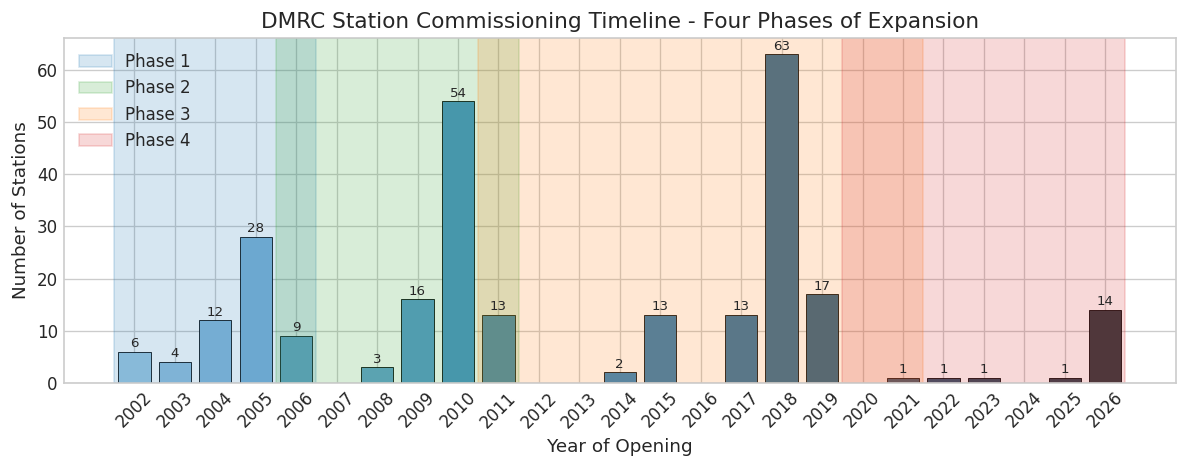

In [31]:
# Dataset Shape Summary
summary = pd.DataFrame({
    'File': ['stops.txt', 'stop_times.txt', 'trips.txt', 'routes.txt', 'wiki_df'],
    'Rows': [len(stops), len(stop_times), len(trips), len(routes), len(wiki_df)],
    'Key Columns': [
        'stop_id, stop_name, stop_lat, stop_lon',
        'trip_id, stop_id, stop_sequence, arrival_time',
        'trip_id, route_id, service_id, shape_id',
        'route_id, route_long_name, route_color',
        'Station name, Line, Opened, Interchange'
    ]
})
display(summary.style.set_properties(**{'text-align': 'left'}).set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#2c3e50'), ('color', 'white')]}]
))

PHASE_PALETTE = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']
# Station Opening Year Distribution 
fig, ax = plt.subplots(figsize =(10, 4))
year_counts = wiki_df['Opening Year'].value_counts().sort_index()
bars = ax.bar(year_counts.index, year_counts.values, color =sns.color_palette("Blues_d", len(year_counts)), edgecolor ='black', linewidth =0.5)
for bar, val in zip(bars, year_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, str(val), ha ='center', va ='bottom', fontsize =8)
# Phase bands
for phase, (start, end, label) in enumerate([(2002, 2006, 'Phase 1'), (2006, 2011, 'Phase 2'), (2011, 2021, 'Phase 3'), (2020, 2026, 'Phase 4')]):
    ax.axvspan(start - 0.5, end + 0.5, alpha =0.18, color =PHASE_PALETTE[phase], label =label)

all_years = range(wiki_df['Opening Year'].min(), wiki_df['Opening Year'].max() + 1)

year_counts = (
    wiki_df['Opening Year']
    .value_counts()
    .reindex(all_years, fill_value =0)
    .sort_index()
)
ax.set_xticks(all_years)
ax.set_xticklabels(all_years, rotation =45)

ax.set_xlabel("Year of Opening")
ax.set_ylabel("Number of Stations")
ax.set_title("DMRC Station Commissioning Timeline - Four Phases of Expansion")
ax.legend(loc ='upper left')
plt.tight_layout()
plt.savefig('Results/DMRC Station Commissioning Timeline - Four Phases of Expansion.png', bbox_inches='tight')
plt.show()

Source: [Delhi Metro Wikipedia](https://en.wikipedia.org/wiki/Delhi_Metro)

---

## Section 2: Network Construction & Baseline Metrics

### 2.1 Graph Construction

We construct the **L-Space** (physical) graph by iterating over each `trip_id` in the filtered stop-times, sorting stops by `stop_sequence`, and adding edges between consecutive stations. This represents the actual track layout.


In [32]:
def construct_topologies(stop_times_df):
    L = nx.Graph()
    P = nx.Graph()

    # L-Space: consecutive station pairs on each trip 
    for _, group in stop_times_df.groupby('trip_id'):
        path = group.sort_values('stop_sequence')['stop_id'].map(stop_id_to_name).tolist()
        L.add_edges_from(zip(path[:-1], path[1:]))

    # P-Space: all station pairs sharing a route 
    route_stop_map = {}
    for trip_id, group in stop_times_df.groupby('trip_id'):
        r_id = trips[trips.trip_id == trip_id]['route_id'].values[0]
        s_names = set(group['stop_id'].map(stop_id_to_name))
        route_stop_map.setdefault(r_id, set()).update(s_names)

    for stations in route_stop_map.values():
        for u, v in combinations(stations, 2):
            P.add_edge(u, v)

    return L, P

L_main, P_main = construct_topologies(st_filtered)

print(f" L-Space (Physical): {L_main.number_of_nodes()} nodes, {L_main.number_of_edges()} edges")
print(f" P-Space (Commuter):  {P_main.number_of_nodes()} nodes, {P_main.number_of_edges()} edges")
print(f"   L-Space connected components: {nx.number_connected_components(L_main)}")
print(f"   P-Space connected components: {nx.number_connected_components(P_main)}")


 L-Space (Physical): 262 nodes, 274 edges
 P-Space (Commuter):  262 nodes, 4564 edges
   L-Space connected components: 2
   P-Space connected components: 2


### 2.2 Network Metrics — Baseline 

We compute a full set of baseline metrics on both representations. All distance-based metrics are computed on the **Giant Connected Component (GCC)** to avoid `NetworkXError` from disconnected graphs.


In [33]:
def get_comprehensive_metrics(G, name):
    giant = G.subgraph(max(nx.connected_components(G), key =len)).copy()
    n, m = G.number_of_nodes(), G.number_of_edges()
    degs = [d for _, d in G.degree()]

    return {
        "Metric": name,
        "Nodes (N)": n,
        "Edges (M)": m,
        "GCC Size": giant.number_of_nodes(),
        "Avg Degree ⟨k⟩": round(np.mean(degs), 3),
        "Max Degree": max(degs),
        "Avg Path Length L": round(nx.average_shortest_path_length(giant), 4),
        "Diameter": nx.diameter(giant),
        "Clustering C": round(nx.average_clustering(G), 5),
        "Density": round(nx.density(G), 6),
        "Global Efficiency Eglob": round(nx.global_efficiency(G), 5),
    }

l_m = get_comprehensive_metrics(L_main, "L-Space")
p_m = get_comprehensive_metrics(P_main, "P-Space")

df_base = pd.DataFrame([l_m, p_m]).set_index("Metric").T
df_base["Ratio P/L"] = (df_base["P-Space"] / df_base["L-Space"]).round(3)

styled = df_base.style \
    .background_gradient(cmap ='Blues', subset =["L-Space", "P-Space"]) \
    .format(precision =4) \
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#1a252f'), ('color', 'white'), ('font-size', '12px')]},
        {'selector': 'td', 'props': [('font-size', '11px')]}
    ]) \
    .set_caption("Table 1: Baseline Network Metrics - L-Space vs P-Space")

display(styled)

print(f"\n P-Space Avg Path Length is {df_base.loc['Avg Path Length L','Ratio P/L']:.2f}x smaller than L-Space.")


Metric,L-Space,P-Space,Ratio P/L
Nodes (N),262.0000,262.0000,1.0000
Edges (M),274.0000,4564.0000,16.6570
GCC Size,241.0000,241.0000,1.0000
Avg Degree ⟨k⟩,2.0920,34.8400,16.6540
Max Degree,5.0000,96.0000,19.2000
Avg Path Length L,17.8508,2.1394,0.1200
Diameter,56.0000,4.0000,0.0710
Clustering C,0.0000,0.9510,inf
Density,0.0080,0.1335,16.6560
Global Efficiency Eglob,0.0755,0.4522,5.9930



 P-Space Avg Path Length is 0.12x smaller than L-Space.


### 2.3 Degree Distribution 

Before the formal power-law test in D2, we inspect the degree distribution of the L-Space graph with four views: histogram, log-log scatter, CDF comparison and a degree rank plot (Zipf plot).


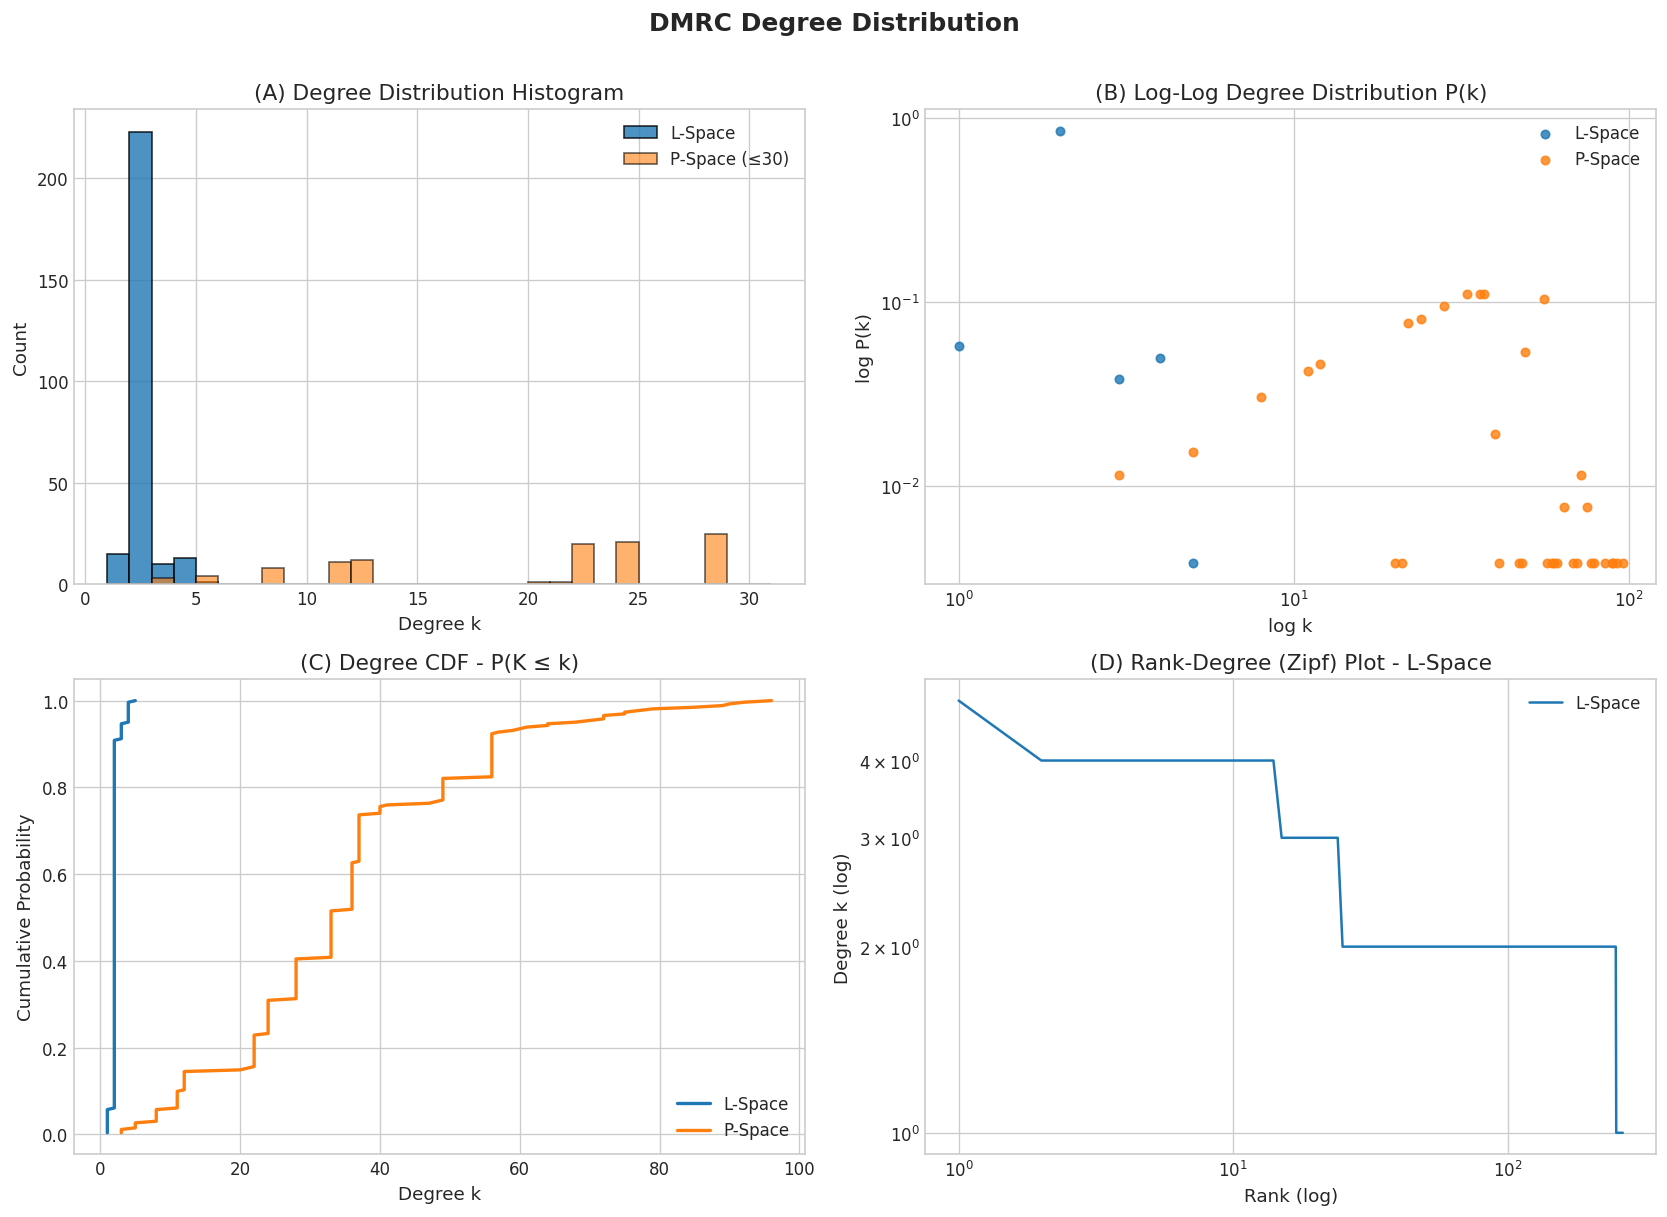

,Mean,Median,Std Dev,Max,Skewness,Kurtosis
Space,,,,,,
L-Space,2.092000,2,0.566000,5,2.181000,7.313000
P-Space,34.840000,33,17.573000,96,0.756000,0.907000


In [34]:
fig, axes = plt.subplots(2, 2, figsize =(14, 10))

l_degs = sorted([d for _, d in L_main.degree()], reverse =True)
p_degs = sorted([d for _, d in P_main.degree()], reverse =True)

# (A) Degree Histogram 
ax = axes[0, 0]
ax.hist(l_degs, bins =range(1, max(l_degs)+2), color =PALETTE[0], edgecolor ='black', alpha =0.8, label ='L-Space')
ax.hist(p_degs, bins =range(1, min(30, max(p_degs))+2), color =PALETTE[1], edgecolor ='black', alpha =0.6, label ='P-Space (≤30)')
ax.set_title("(A) Degree Distribution Histogram")
ax.set_xlabel("Degree k")
ax.set_ylabel("Count")
ax.legend()

# (B) Log-Log P(k) 
ax = axes[0, 1]
for degs, name, col in [(l_degs, "L-Space", PALETTE[0]), (p_degs, "P-Space", PALETTE[1])]:
    pk = pd.Series(degs).value_counts().sort_index()
    ax.scatter(pk.index, pk.values / len(degs), s =25, color =col, label =name, alpha =0.8)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_title("(B) Log-Log Degree Distribution P(k)")
ax.set_xlabel("log k"); ax.set_ylabel("log P(k)")
ax.legend()

# (C) CDF Comparison 
ax = axes[1, 0]
for degs, name, col in [(l_degs, "L-Space", PALETTE[0]), (p_degs, "P-Space", PALETTE[1])]:
    s = sorted(degs)
    cdf = np.arange(1, len(s)+1) / len(s)
    ax.plot(s, cdf, color =col, lw =2, label =name)
ax.set_title("(C) Degree CDF - P(K ≤ k)")
ax.set_xlabel("Degree k"); ax.set_ylabel("Cumulative Probability")
ax.legend()

# (D) Rank-Degree Plot (Zipf) 
ax = axes[1, 1]
ax.plot(range(1, len(l_degs)+1), l_degs, color =PALETTE[0], lw =1.5, label ='L-Space')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_title("(D) Rank-Degree (Zipf) Plot - L-Space")
ax.set_xlabel("Rank (log)"); ax.set_ylabel("Degree k (log)")
ax.legend()

plt.suptitle("DMRC Degree Distribution", fontsize =15, fontweight ='bold', y =1.01)
plt.tight_layout()
plt.savefig('Results/DMRC Degree Distribution', bbox_inches='tight')
plt.show()

# Degree stats table
deg_stats = []
for G, name in [(L_main, "L-Space"), (P_main, "P-Space")]:
    d = [k for _, k in G.degree()]
    deg_stats.append({
        "Space": name, "Mean": round(np.mean(d), 3), "Median": int(np.median(d)),
        "Std Dev": round(np.std(d), 3), "Max": max(d), "Skewness": round(pd.Series(d).skew(), 3),
        "Kurtosis": round(pd.Series(d).kurt(), 3)
    })
display(pd.DataFrame(deg_stats).set_index("Space") \
    .style.background_gradient(cmap ='Oranges') \
    .set_caption("Table 2: Degree Distribution Descriptive Statistics"))


### 2.4 Geospatial Network Visualization

We visualize the DMRC network geospatially, using station coordinates from the GTFS feed. Each metro line is assigned its **official DMRC colour** (extracted from `routes.txt` `route_color` field). Node size encodes **betweenness centrality** — stations at the visual crossroads of the network are shown as larger circles.


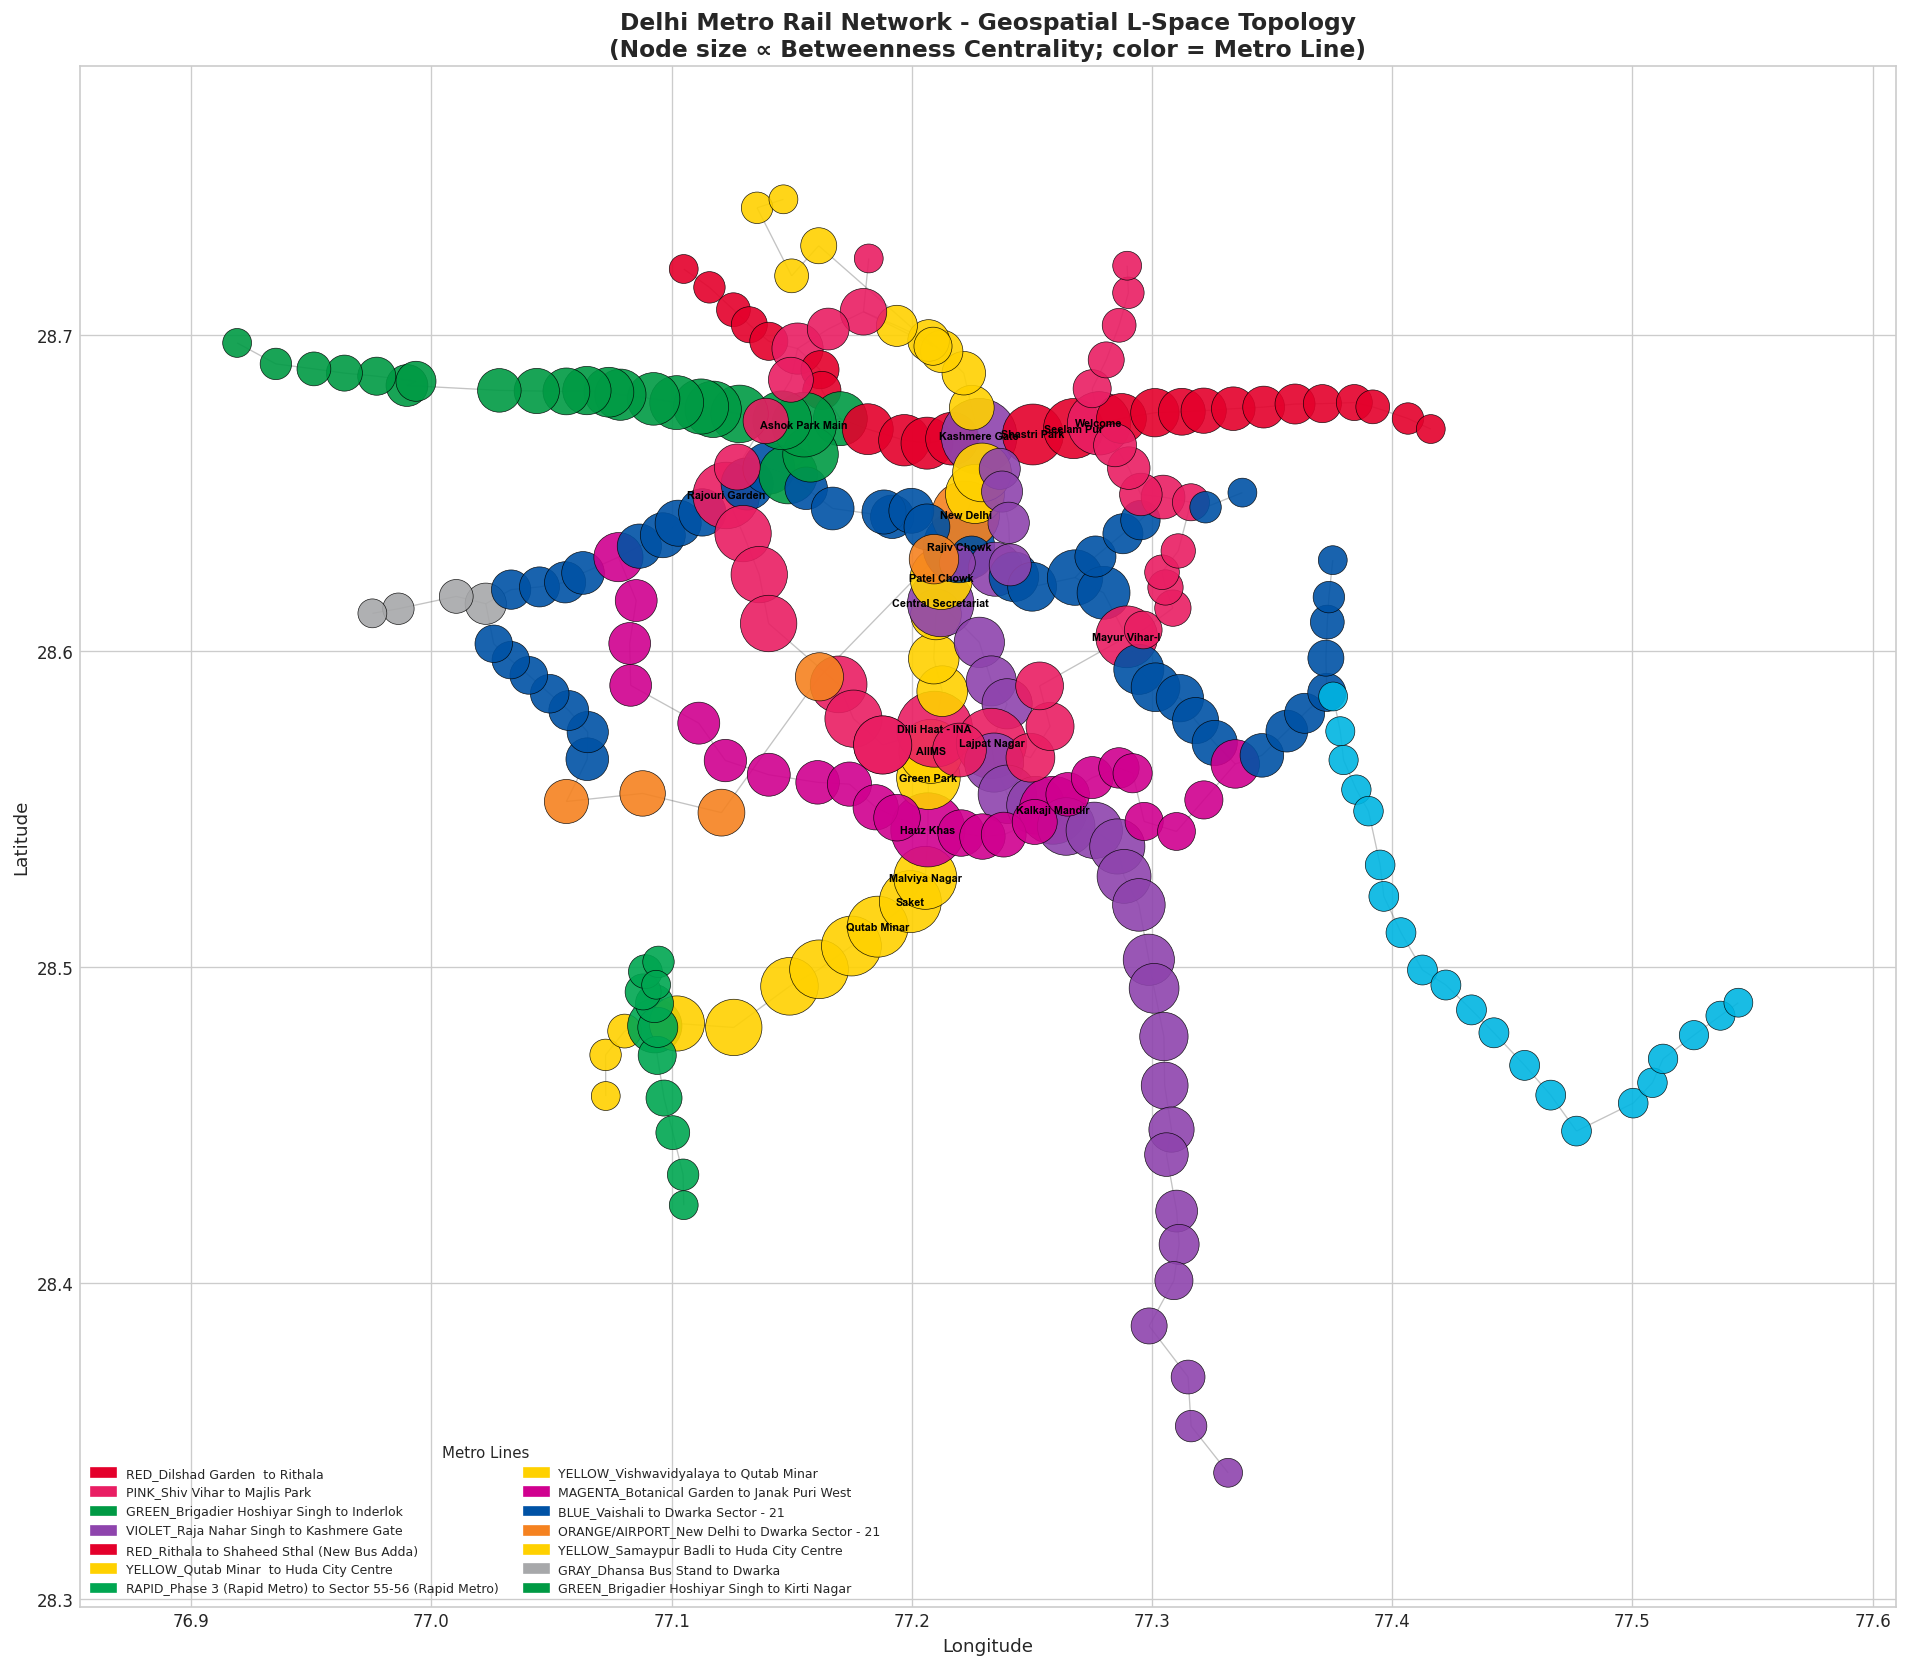

In [35]:
# Build per-line color mapping 
line_colors = {}
for _, row in routes.iterrows():
    color = str(row.get('route_color', '')).strip()
    if color and color.lower() not in ('nan', ''):
        line_colors[row['route_id']] = '#' + color if not color.startswith('#') else color
    else:
        line_colors[row['route_id']] = '#888888'

# Assign dominant line to each station 
station_line = {}
for trip_id, group in st_filtered.groupby('trip_id'):
    r_id = trips[trips.trip_id == trip_id]['route_id'].values[0]
    for s_id in group['stop_id']:
        sname = stop_id_to_name.get(s_id)
        if sname:
            station_line[sname] = r_id   

# Node positions from GTFS coordinates 
pos = {}
for node in L_main.nodes():
    if node in stop_name_to_coords:
        c = stop_name_to_coords[node]
        pos[node] = (c['stop_lon'], c['stop_lat'])

positioned = {n: p for n, p in pos.items() if n in L_main}
L_geo = L_main.subgraph(list(positioned.keys())).copy()

# Betweenness for node sizing
bc = nx.betweenness_centrality(L_geo, normalized =True)
node_sizes = [300 + bc.get(n, 0) * 8000 for n in L_geo.nodes()]
node_colors = [line_colors.get(station_line.get(n, ''), '#cccccc') for n in L_geo.nodes()]

fig, ax = plt.subplots(figsize =(16, 14))
nx.draw_networkx_edges(L_geo, pos =positioned, alpha =0.35, width =0.8, edge_color ='#555555', ax =ax)
nx.draw_networkx_nodes(L_geo, pos =positioned, node_size =node_sizes, node_color =node_colors,
                       alpha =0.9, linewidths =0.4, edgecolors ='black', ax =ax)

# Label only high-betweenness stations (top 20)
top_bc = sorted(bc, key =bc.get, reverse =True)[:20]
label_dict = {n: n for n in top_bc if n in positioned}
nx.draw_networkx_labels(L_geo, pos =positioned, labels =label_dict, font_size =6.5,
                        font_weight ='bold', ax =ax)
route_names = dict(zip(routes['route_id'], routes.get('route_long_name', routes['route_id'])))
seen = {}
for n in L_geo.nodes():
    rid = station_line.get(n)
    if rid and rid not in seen:
        seen[rid] = line_colors.get(rid, '#888')
legend_patches = [mpatches.Patch(color =col, label =route_names.get(rid, rid)[:])
                  for rid, col in list(seen.items())[:14]]
ax.legend(handles =legend_patches, loc ='lower left', fontsize =7.5, title ="Metro Lines",
          title_fontsize =9, framealpha =0.9, ncol =2)

ax.set_title("Delhi Metro Rail Network - Geospatial L-Space Topology\n"
             "(Node size ∝ Betweenness Centrality; color = Metro Line)", fontsize =14, fontweight ='bold')
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.tick_params(left =True, bottom =True, labelleft =True, labelbottom =True)
plt.tight_layout()
plt.savefig('Results/Delhi Metro Rail Network - Geospatial L-Space Topology_(Node size ∝ Betweenness Centrality; color = Metro Line)', bbox_inches='tight')
plt.show()

---

## D1: Dual-Topology Construction — L-Space vs P-Space

The same metro system can be modelled in two fundamentally different ways:

| Representation | Graph Definition | What it Measures |
|---|---|---|
| **L-Space** (Line Space) | Two stations are connected if they are **physically adjacent** on a track | True topological distance — number of stops to travel |
| **P-Space** (Public Transport Space) | Two stations are connected if they **share at least one metro line** | Functional accessibility — can I travel between them without changing lines? |

In P-Space, every station on a given line forms a **complete clique** — they are all mutually connected. This dramatically compresses the average path length. 
For example: a commuter at Dwarka who can board a train to HUDA City Centre without changing lines experiences P-Space, not L-Space.

> In P-Space, if a route serves stations $\{s_1, s_2, ..., s_k\}$, we add all $\binom{k}{2}$ edges. The resulting graph's average path length $L_P \ll L_L$ because a single "hop" in P-Space can represent travelling dozens of physical stops.

### 1.1 Topology Comparison


In [36]:
metrics_display = {
    "Avg Path Length L": (l_m["Avg Path Length L"], p_m["Avg Path Length L"]),
    "Clustering Coeff C": (l_m["Clustering C"], p_m["Clustering C"]),
    "Diameter": (l_m["Diameter"], p_m["Diameter"]),
    "Global Efficiency Eglob": (l_m["Global Efficiency Eglob"], p_m["Global Efficiency Eglob"]),
    "Density": (l_m["Density"], p_m["Density"]),
    "Avg Degree ⟨k⟩": (l_m["Avg Degree ⟨k⟩"], p_m["Avg Degree ⟨k⟩"]),
}

df_d1 = pd.DataFrame(metrics_display, index =['L-Space', 'P-Space']).T
df_d1["Ratio (P/L)"] = (df_d1["P-Space"] / df_d1["L-Space"]).round(3)
df_d1["Interpretation"] = [
    "P-space is dramatically shorter - commuter 'hops' are fewer",
    "P-space has near-perfect clustering (clique formation)",
    "Maximum network traversal drops drastically",
    "P-space is far more efficient for routing",
    "P-space is denser due to all-pairs edges per line",
    "P-space hubs have far more connections",
]

display(df_d1.style
    .background_gradient(cmap ='YlOrRd', subset =["L-Space", "P-Space"])
    .bar(subset =["Ratio (P/L)"], color ='#5fba7d')
    .set_caption("Table 3: L-Space vs P-Space - Comparative Topology Metrics"))


,L-Space,P-Space,Ratio (P/L),Interpretation
Avg Path Length L,17.850800,2.139400,0.120000,P-space is dramatically shorter - commuter 'hops' are fewer
Clustering Coeff C,0.000000,0.951030,inf,P-space has near-perfect clustering (clique formation)
Diameter,56.000000,4.000000,0.071000,Maximum network traversal drops drastically
Global Efficiency Eglob,0.075460,0.452220,5.993000,P-space is far more efficient for routing
Density,0.008014,0.133485,16.656000,P-space is denser due to all-pairs edges per line
Avg Degree ⟨k⟩,2.092000,34.840000,16.654000,P-space hubs have far more connections


### 1.2 Small-World Assessment

A network is classified as **Small-World** if it simultaneously satisfies:
- $L \approx L_{rand}$ (short average path length, comparable to a random graph)
- $C \gg C_{rand}$ (high clustering coefficient, much greater than random)

The **Small-World coefficient** $\sigma$ is defined as:
$$\sigma = \frac{C / C_{rand}}{L / L_{rand}}$$

$\sigma > 1$ confirms Small-World behaviour. We compute this for both representations.


,Space,C (observed),C_rand,L (observed),L_rand,σ (Small-World Index),Classification
0,L-Space,0.000000,0.008010,17.851000,7.507000,0.000000,Not SW ❌
1,P-Space,0.951030,0.133490,2.139000,1.567000,5.220000,Small-World ✅


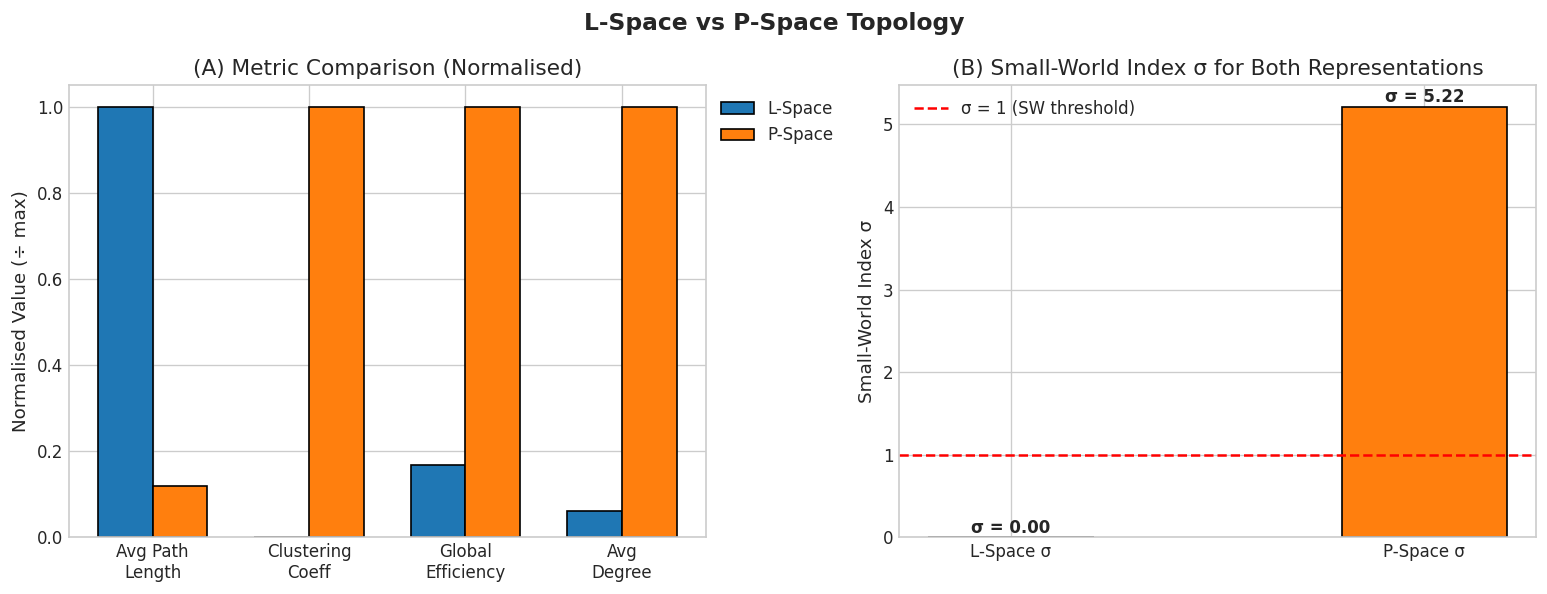

In [ ]:
n = L_main.number_of_nodes()
m = L_main.number_of_edges()
p_rand = 2 * m / (n * (n - 1))

# Random graph benchmarks (analytical for ER)
C_rand = p_rand
L_rand_approx = np.log(n) / np.log(n * p_rand)  # ER approximation

C_L = nx.average_clustering(L_main)
giant_L = L_main.subgraph(max(nx.connected_components(L_main), key =len))
L_L = nx.average_shortest_path_length(giant_L)

sigma_L = (C_L / C_rand) / (L_L / L_rand_approx)

# P-Space
n_p = P_main.number_of_nodes()
m_p = P_main.number_of_edges()
p_rand_p = 2 * m_p / (n_p * (n_p - 1))
C_rand_p = p_rand_p
L_rand_p = np.log(n_p) / np.log(max(n_p * p_rand_p, 2))
C_P = nx.average_clustering(P_main)
giant_P = P_main.subgraph(max(nx.connected_components(P_main), key =len))
L_P = nx.average_shortest_path_length(giant_P)
sigma_P = (C_P / C_rand_p) / (L_P / L_rand_p)

sw_df = pd.DataFrame({
    "Space": ["L-Space", "P-Space"],
    "C (observed)": [round(C_L, 5), round(C_P, 5)],
    "C_rand": [round(C_rand, 5), round(C_rand_p, 5)],
    "L (observed)": [round(L_L, 3), round(L_P, 3)],
    "L_rand": [round(L_rand_approx, 3), round(L_rand_p, 3)],
    "σ (Small-World Index)": [round(sigma_L, 2), round(sigma_P, 2)],
    "Classification": ["Small-World ✅" if sigma_L > 1 else "Not SW ❌",
                        "Small-World ✅" if sigma_P > 1 else "Not SW ❌"]
})
display(sw_df.style
    .map(lambda v: 'color: green; font-weight: bold' if '✅' in str(v) else '', subset =["Classification"])
    .set_caption("Table 4: Small-World Index σ = (C/C_rand) / (L/L_rand)"))

# Radar / Bar comparison chart 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize =(13, 5))

# Normalised metric comparison bar chart
categories = ['Avg Path\nLength', 'Clustering\nCoeff', 'Global\nEfficiency', 'Avg\nDegree']
l_vals = [L_L, C_L, l_m["Global Efficiency Eglob"], l_m["Avg Degree ⟨k⟩"]]
p_vals = [L_P, C_P, p_m["Global Efficiency Eglob"], p_m["Avg Degree ⟨k⟩"]]
# Normalise each to max for visual comparison
norms = [max(l_vals[i], p_vals[i]) for i in range(4)]
l_norm = [v/n_ for v, n_ in zip(l_vals, norms)]
p_norm = [v/n_ for v, n_ in zip(p_vals, norms)]

x = np.arange(len(categories))
w = 0.35
ax1.bar(x - w/2, l_norm, w, label ='L-Space', color =PALETTE[0], edgecolor ='black')
ax1.bar(x + w/2, p_norm, w, label ='P-Space', color =PALETTE[1], edgecolor ='black')
ax1.set_xticks(x); ax1.set_xticklabels(categories)
ax1.set_ylabel("Normalised Value (÷ max)")
ax1.set_title("(A) Metric Comparison (Normalised)")
ax1.legend(loc ='upper left', bbox_to_anchor =(1, 1))

# Small-World sigma comparison
ax2.bar(["L-Space σ", "P-Space σ"], [sigma_L, sigma_P], color =[PALETTE[0], PALETTE[1]], edgecolor ='black', width =0.4)
ax2.axhline(1, color ='red', linestyle ='--', linewidth =1.5, label ='σ = 1 (SW threshold)')
ax2.set_ylabel("Small-World Index σ")
ax2.set_title("(B) Small-World Index σ for Both Representations")
ax2.legend()
for i, v in enumerate([sigma_L, sigma_P]):
    ax2.text(i, v + 0.05, f"σ = {v:.2f}", ha ='center', fontweight ='bold')

plt.suptitle("L-Space vs P-Space Topology", fontsize =14, fontweight ='bold')
plt.tight_layout()
plt.savefig('Results/L-Space vs P-Space Topology', bbox_inches='tight')
plt.show()


---

## D2: Scale-Free Testing, Degree Analysis & Temporal Network Evolution

A **Scale-Free network** is characterised by a degree distribution that follows a **power law**:
$$P(k) \sim k^{-\gamma}$$
where $\gamma$ is the scaling exponent. Networks generated by **Preferential Attachment** (Barabási–Albert model) exhibit $2 < \gamma < 3$.

For transit networks, the scale-free hypothesis is contested: unlike the internet or citation graphs where "the rich get richer" naturally, metro networks are **planned** with capacity constraints. We use the `powerlaw` library's Maximum Likelihood Estimation (MLE) method to fit and statistically test the hypothesis.

### 2.1 Power Law Fitting 


In [ ]:
def analyze_scaling_rigor(G, label ="L-Space"):
    degrees = [d for n, d in G.degree() if d > 0]
    fit = powerlaw.Fit(degrees, discrete =True, verbose =False)

    R_exp, p_exp = fit.distribution_compare('power_law', 'exponential')
    R_log, p_log = fit.distribution_compare('power_law', 'lognormal')
    R_trunc, p_trunc = fit.distribution_compare('power_law', 'truncated_power_law')

    results = {
        "Network": label,
        "α (Power Law γ)": round(fit.alpha, 4),
        "x_min": fit.xmin,
        "KS Distance D": round(fit.D, 4),
        "R vs Exponential": round(R_exp, 4),
        "p (vs Exp)": round(p_exp, 4),
        "R vs Log-Normal": round(R_log, 4),
        "R vs Truncated PL": round(R_trunc, 4),
        "Verdict": "Power Law favoured" if R_exp > 0 else "Exponential favoured"
    }
    return results, fit

results_L, fit_L = analyze_scaling_rigor(L_main, "L-Space")
results_P, fit_P = analyze_scaling_rigor(P_main, "P-Space")

fit_df = pd.DataFrame([results_L, results_P]).set_index("Network")
display(fit_df.style
    .map(lambda v: 'color: green; font-weight: bold' if 'Power Law' in str(v) else
              ('color: red' if 'Exponential' in str(v) else ''), subset =["Verdict"])
    .background_gradient(cmap ='Blues', subset =["α (Power Law γ)", "KS Distance D"])
    .set_caption("Table 5: MLE Power Law Fitting - Statistical Test Results"))


,α (Power Law γ),x_min,KS Distance D,R vs Exponential,p (vs Exp),R vs Log-Normal,R vs Truncated PL,Verdict
Network,,,,,,,,
L-Space,1.867600,1.000000,0.501700,-118.960400,0.000000,-303.152900,-118.960300,Exponential favoured
P-Space,2.855400,22.000000,0.238000,-24.035200,0.000000,-26.111400,-24.035100,Exponential favoured


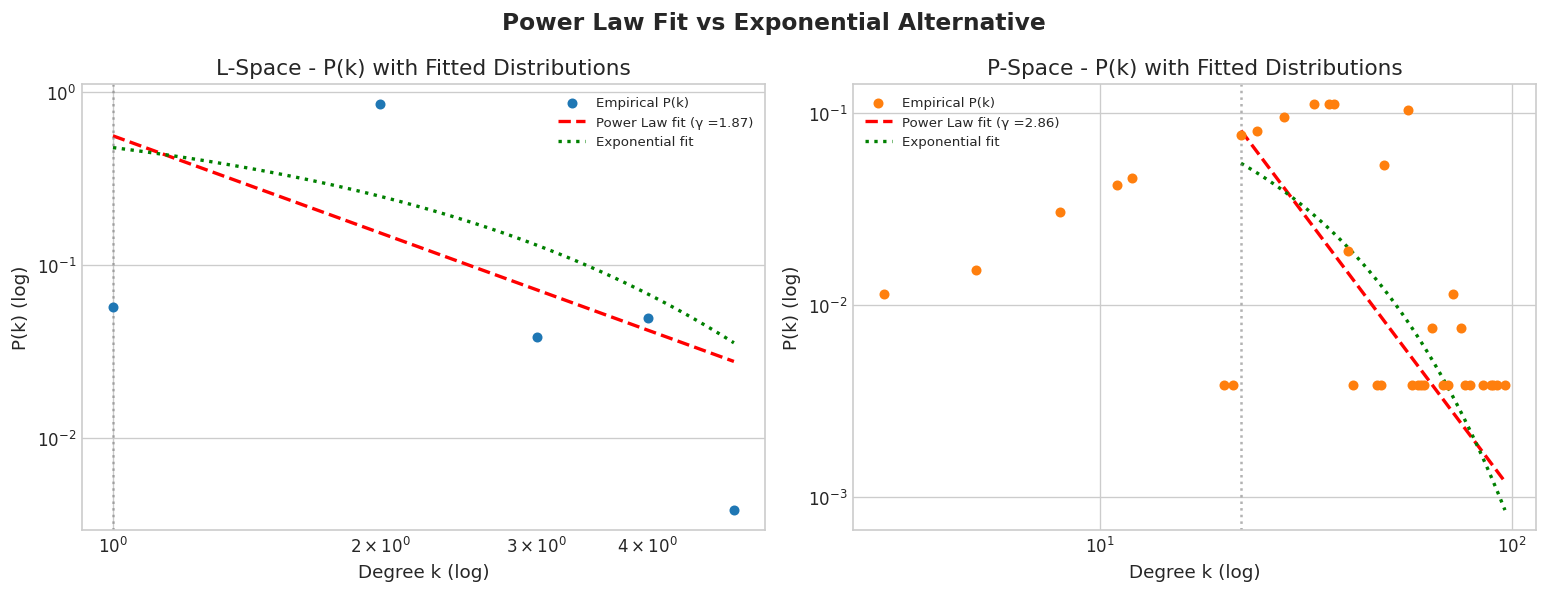

In [39]:
# Power Law Visual Fit
fig, axes = plt.subplots(1, 2, figsize =(13, 5))

for ax, fit, G, label, col in [(axes[0], fit_L, L_main, "L-Space", PALETTE[0]),
                                (axes[1], fit_P, P_main, "P-Space", PALETTE[1])]:
    degrees = [d for _, d in G.degree() if d > 0]
    pk = pd.Series(degrees).value_counts().sort_index()
    pk_norm = pk / len(degrees)

    ax.scatter(pk_norm.index, pk_norm.values, s =25, color =col, zorder =5, label ='Empirical P(k)')

    # Power law fit line
    k_range = np.linspace(fit.xmin, max(degrees), 100)
    pl_vals = fit.power_law.pdf(k_range)
    ax.plot(k_range, pl_vals, 'r--', lw =2, label =f'Power Law fit (γ ={fit.alpha:.2f})')

    # Exponential fit line
    exp_vals = fit.exponential.pdf(k_range)
    ax.plot(k_range, exp_vals, 'g:', lw =2, label ='Exponential fit')

    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_title(f"{label} - P(k) with Fitted Distributions")
    ax.set_xlabel("Degree k (log)"); ax.set_ylabel("P(k) (log)")
    ax.legend(fontsize =8)
    ax.axvline(fit.xmin, color ='gray', linestyle =':', alpha =0.6, label =f'x_min ={fit.xmin}')

plt.suptitle("Power Law Fit vs Exponential Alternative", fontsize =14, fontweight ='bold')
plt.tight_layout()
plt.savefig('Results/Power Law Fit vs Exponential Alternative', bbox_inches='tight')
plt.show()

### 2.2 Benchmark Against Synthetic Network Models

We compare the DMRC's structural fingerprint against four canonical network models with the **same number of nodes and edges**. 

| Model | Construction | Expected Properties |
|---|---|---|
| **Erdős–Rényi (ER)** | Edges added uniformly at random | Short paths, low clustering |
| **Watts–Strogatz (WS)** | Regular ring + random rewiring | High clustering, short paths (tunable) |
| **Barabási–Albert (BA)** | Preferential attachment growth | Power-law degree, scale-free |
| **DMRC Real** | Planned transit network | Transit-constrained topology |


,Avg Path L,Clustering C,Diameter,Avg Degree,Max Degree,Global Efficiency
Model,,,,,,
DMRC Real,17.851000,0.000000,56,2.090000,5,0.075500
Erdős–Rényi,6.396000,0.006800,16,2.090000,9,0.120100
Watts–Strogatz,6.496000,0.371600,13,4.000000,7,0.184800
Barabási–Albert,3.358000,0.102100,6,3.970000,50,0.324400


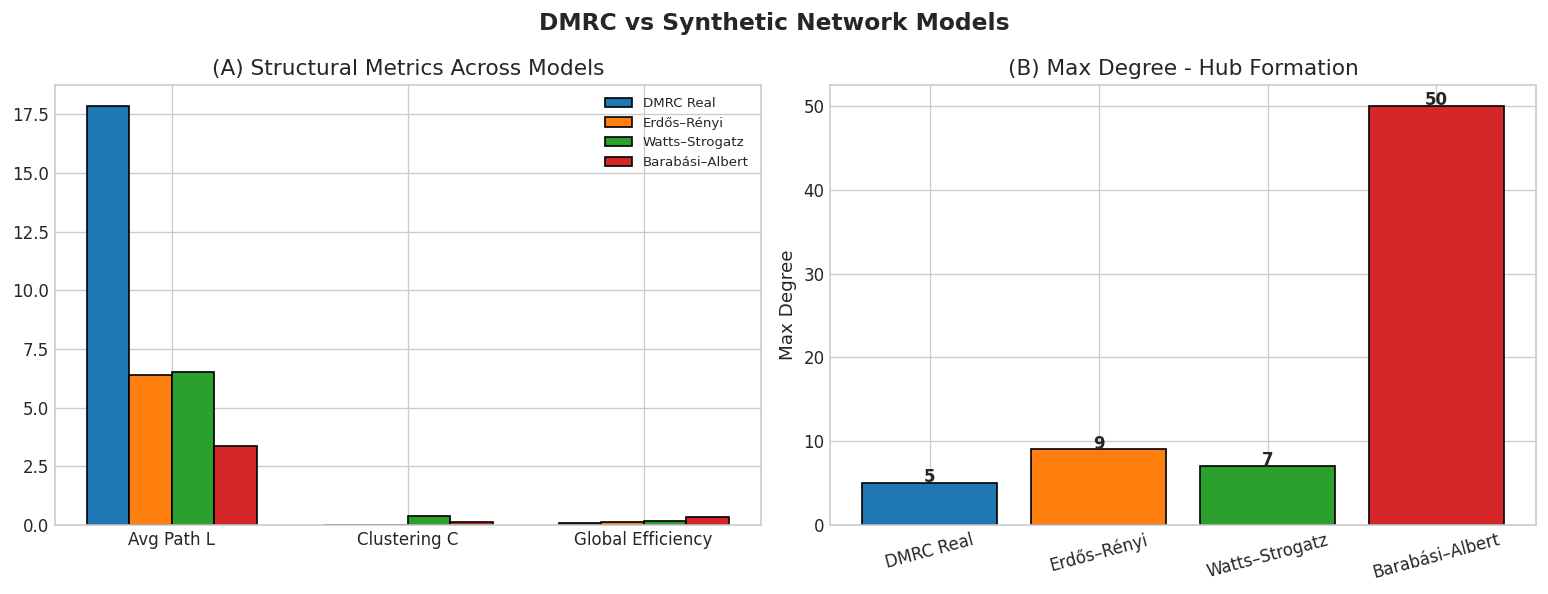

In [ ]:
n_nodes = L_main.number_of_nodes()
m_edges = L_main.number_of_edges()

models = {
    "DMRC Real": L_main,
    "Erdős–Rényi": nx.gnm_random_graph(n_nodes, m_edges, seed =SEED),
    "Watts–Strogatz": nx.watts_strogatz_graph(n_nodes, k =4, p =0.1, seed =SEED),
    "Barabási–Albert": nx.barabasi_albert_graph(n_nodes, m =2, seed =SEED),
}

comparison_data = []
for name, model in models.items():
    gcc = model.subgraph(max(nx.connected_components(model), key =len))
    degs = [d for _, d in model.degree()]
    comparison_data.append({
        "Model": name,
        "Avg Path L": round(nx.average_shortest_path_length(gcc), 3),
        "Clustering C": round(nx.average_clustering(model), 4),
        "Diameter": nx.diameter(gcc),
        "Avg Degree": round(np.mean(degs), 2),
        "Max Degree": max(degs),
        "Global Efficiency": round(nx.global_efficiency(model), 4),
    })

comp_df = pd.DataFrame(comparison_data).set_index("Model")
display(comp_df.style
    .background_gradient(cmap ='Greens', subset =["Avg Path L", "Clustering C", "Global Efficiency"])
    .highlight_max(subset =["Clustering C", "Global Efficiency"], color ='#d4edda')
    .highlight_min(subset =["Avg Path L", "Diameter"], color ='#d4edda')
    .set_caption("Table 6: DMRC vs Canonical Network Models (N and M held constant)"))

# Radar Chart 
fig, axes = plt.subplots(1, 2, figsize =(13, 5))

metrics = ["Avg Path L", "Clustering C", "Global Efficiency"]
x = np.arange(len(metrics))
w = 0.18

for i, (name, col) in enumerate(zip(comp_df.index, PALETTE)):
    vals = [comp_df.loc[name, m] for m in metrics]
    axes[0].bar(x + i*w, vals, w, label =name, color =col, edgecolor ='black')

axes[0].set_xticks(x + w*1.5)
axes[0].set_xticklabels(metrics)
axes[0].set_title("(A) Structural Metrics Across Models")
axes[0].legend(fontsize =8)

# Max Degree comparison (hub formation)
axes[1].bar(comp_df.index, comp_df["Max Degree"], color =PALETTE[:4], edgecolor ='black')
axes[1].set_title("(B) Max Degree - Hub Formation")
axes[1].set_ylabel("Max Degree")
axes[1].tick_params(axis ='x', rotation =15)
for i, v in enumerate(comp_df["Max Degree"]):
    axes[1].text(i, v + 0.1, str(v), ha ='center', fontweight ='bold')

plt.suptitle("DMRC vs Synthetic Network Models", fontsize =14, fontweight ='bold')
plt.tight_layout()
plt.savefig('Results/DMRC vs Synthetic Network Models', bbox_inches='tight')
plt.show()


### 2.3 Temporal Network Evolution — Phase-by-Phase Growth

We reconstruct the DMRC at each of its four construction phases and measure how key network properties evolved as the system expanded. This reveals whether efficiency was gained incrementally or in structural "jumps".


,Year,Stations,Edges,Avg Path Length,Clustering C,Global Efficiency,γ (Gamma),Diameter
Phase,,,,,,,,
Phase 1,2006,28,14,2.000000,0.000000,0.048300,nan,4
Phase 2,2011,78,46,2.381000,0.000000,0.021600,nan,5
Phase 3,2021,149,115,6.034000,0.000000,0.027000,2.173000,15
Phase 4,2026,262,274,17.851000,0.000000,0.075500,1.868000,56


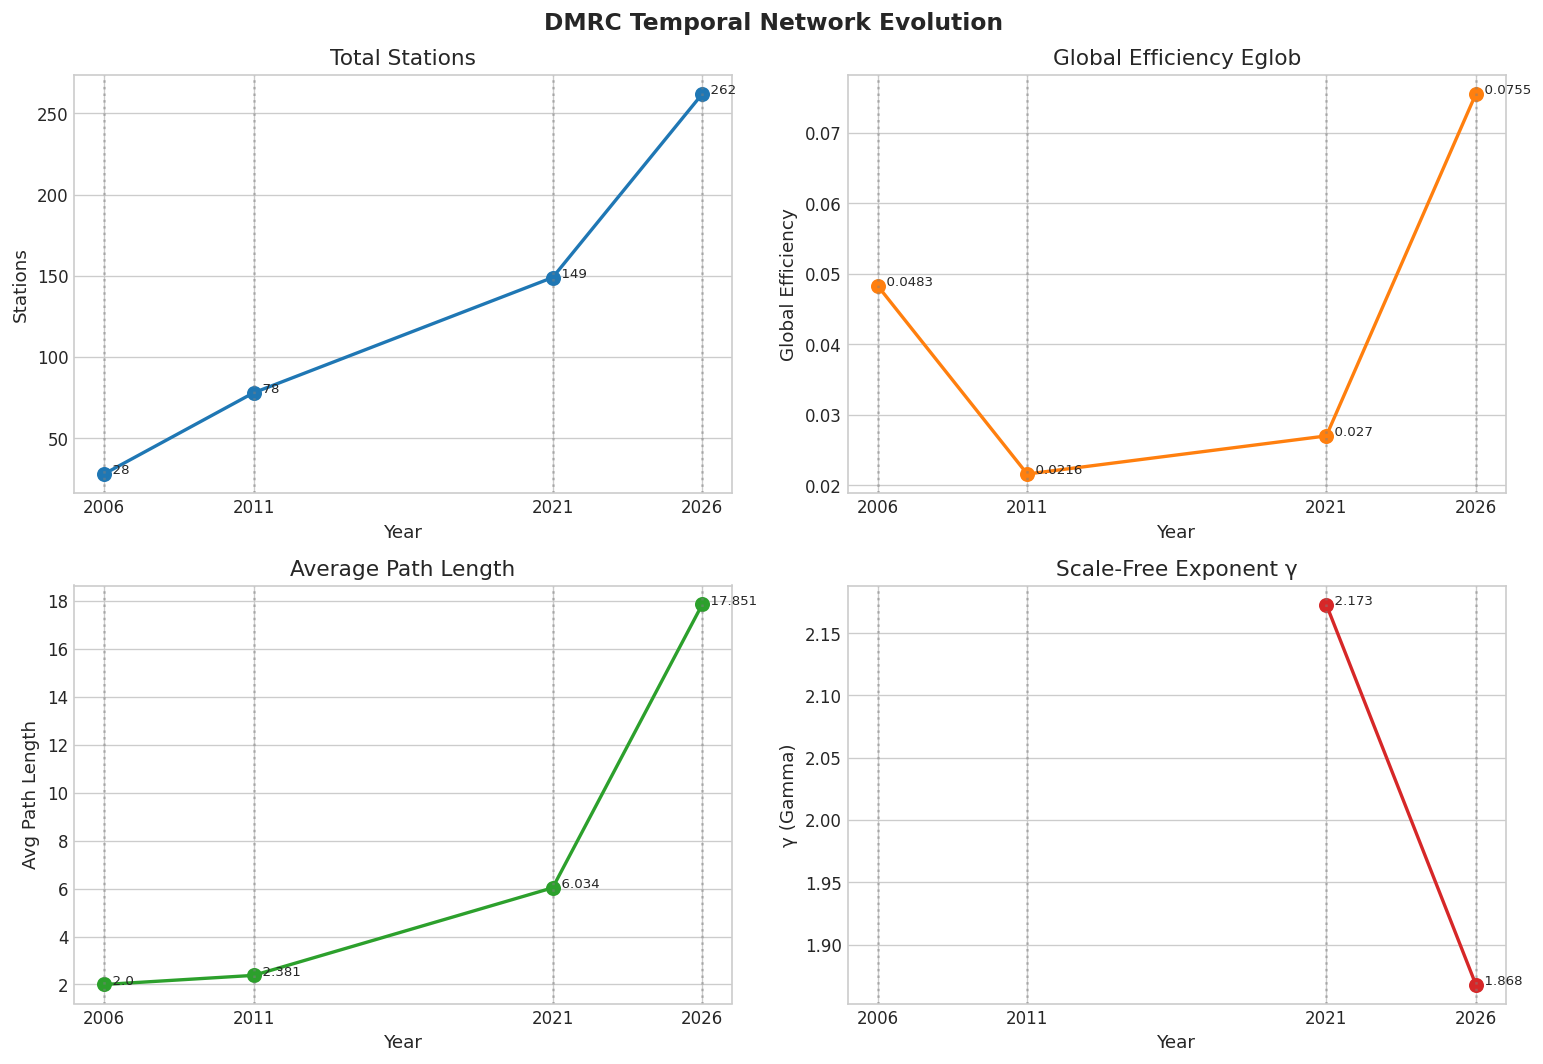

In [ ]:
milestones = [2006, 2011, 2021, 2026]
temporal_metrics = []

for year in milestones:
    valid_nodes = [n for n in L_main.nodes() if opening_lookup.get(n, 2026) <= year]
    G_sub = L_main.subgraph(valid_nodes)
    if G_sub.number_of_nodes() < 10:
        continue
    gcc = G_sub.subgraph(max(nx.connected_components(G_sub), key =len))
    degrees = [d for _, d in G_sub.degree() if d > 0]
    fit = powerlaw.Fit(degrees, discrete =True, verbose =False)
    temporal_metrics.append({
        "Phase": f"Phase {'1234'[milestones.index(year)]}",
        "Year": year,
        "Stations": G_sub.number_of_nodes(),
        "Edges": G_sub.number_of_edges(),
        "Avg Path Length": round(nx.average_shortest_path_length(gcc), 3),
        "Clustering C": round(nx.average_clustering(G_sub), 4),
        "Global Efficiency": round(nx.global_efficiency(G_sub), 4),
        "γ (Gamma)": round(fit.alpha, 3),
        "Diameter": nx.diameter(gcc)
    })

df_evo = pd.DataFrame(temporal_metrics)
display(df_evo.set_index("Phase").style
    .background_gradient(cmap ='Blues', subset =["Stations", "Edges", "Global Efficiency"])
    .set_caption("Table 7: DMRC Network Properties at Each Construction Phase"))

# Temporal Evolution Plots
fig, axes = plt.subplots(2, 2, figsize =(13, 9))

metrics_plot = [
    ("Stations", "Total Stations", PALETTE[0]),
    ("Global Efficiency", "Global Efficiency Eglob", PALETTE[1]),
    ("Avg Path Length", "Average Path Length", PALETTE[2]),
    ("γ (Gamma)", "Scale-Free Exponent γ", PALETTE[3]),
]

for ax, (col, title, c) in zip(axes.flatten(), metrics_plot):
    ax.plot(df_evo["Year"], df_evo[col], marker ='o', markersize =8, lw =2, color =c)
    for _, row in df_evo.iterrows():
        ax.annotate(f"  {row[col]}", (row["Year"], row[col]), fontsize =8)
    for yr in milestones:
        ax.axvline(yr, color ='gray', linestyle =':', alpha =0.5)
    ax.set_xticks(milestones)
    ax.set_xlabel("Year")
    ax.set_ylabel(col)
    ax.set_title(title)

plt.suptitle("DMRC Temporal Network Evolution", fontsize =14, fontweight ='bold')
plt.tight_layout()
plt.savefig('Results/DMRC Temporal Network Evolution', bbox_inches='tight')
plt.show()

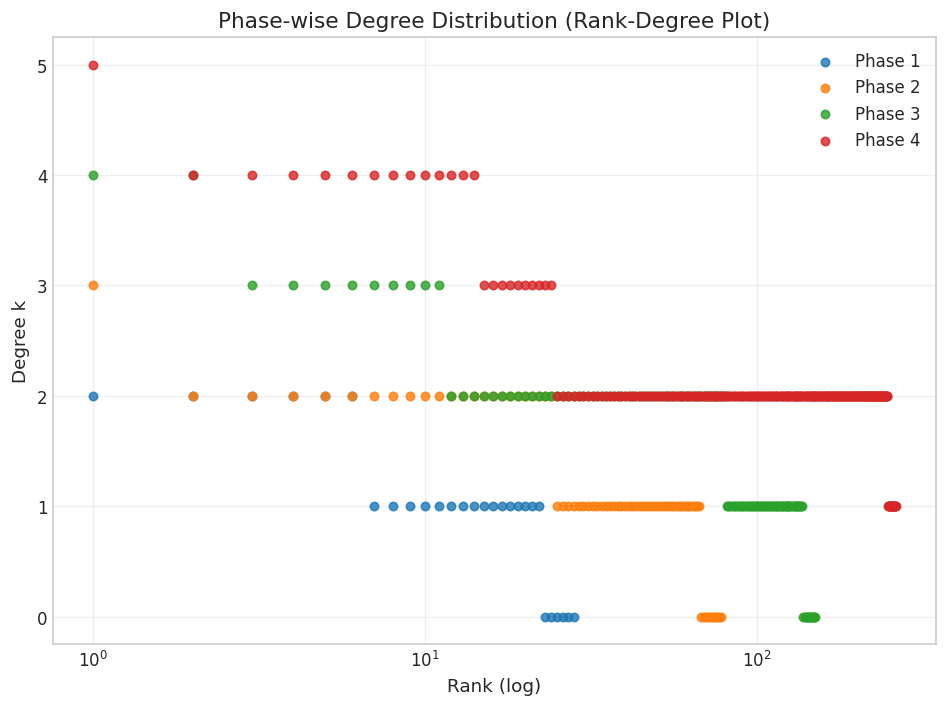

In [42]:
# Phase-wise Degree Scatter (Degree vs Rank)

import matplotlib.pyplot as plt
import numpy as np

phases = {
    "Phase 1": 2006,
    "Phase 2": 2011,
    "Phase 3": 2021,
    "Phase 4": 2026
}

plt.figure(figsize =(8,6))

for phase, year in phases.items():

    valid_nodes = [n for n in L_main.nodes() if opening_lookup.get(n, 2026) <= year]
    G_sub = L_main.subgraph(valid_nodes)
    
    # Degree list (sorted)
    degrees = sorted([d for _, d in G_sub.degree()], reverse =True)
    
    # Rank 
    ranks = np.arange(1, len(degrees)+1)
    
    # Scatter
    plt.scatter(ranks, degrees, s =25, alpha =0.8, label =phase)

plt.xscale('log')

plt.xlabel("Rank (log)")
plt.ylabel("Degree k")
plt.title("Phase-wise Degree Distribution (Rank-Degree Plot)")
plt.legend()
plt.grid(alpha =0.3)

plt.tight_layout()
plt.savefig('Results/Phase-wise Degree Distribution (Rank-Degree Plot)', bbox_inches='tight')
plt.show()

---

## D3: Targeted Attack & Cascading Failure Simulation

Following **Albert, Jeong & Barabási (2000)**, we simulate two types of network degradation:

1. **Random Failure** — Nodes removed uniformly at random (models accidents, equipment failures)
2. **Targeted Attack** — Nodes removed in decreasing order of centrality (models deliberate closures)

We track three metrics as nodes are sequentially removed:
- **GCC Fraction** — What fraction of the original network remains reachable?
- **Global Efficiency Eglob** — How efficiently can remaining stations communicate?
- **Algebraic Connectivity λ₂** — How close is the network to splitting (Fiedler value)?

We test **five attack strategies** to determine which centrality measure best identifies the most critical stations.

### 3.1 Multi-Strategy Attack Simulation


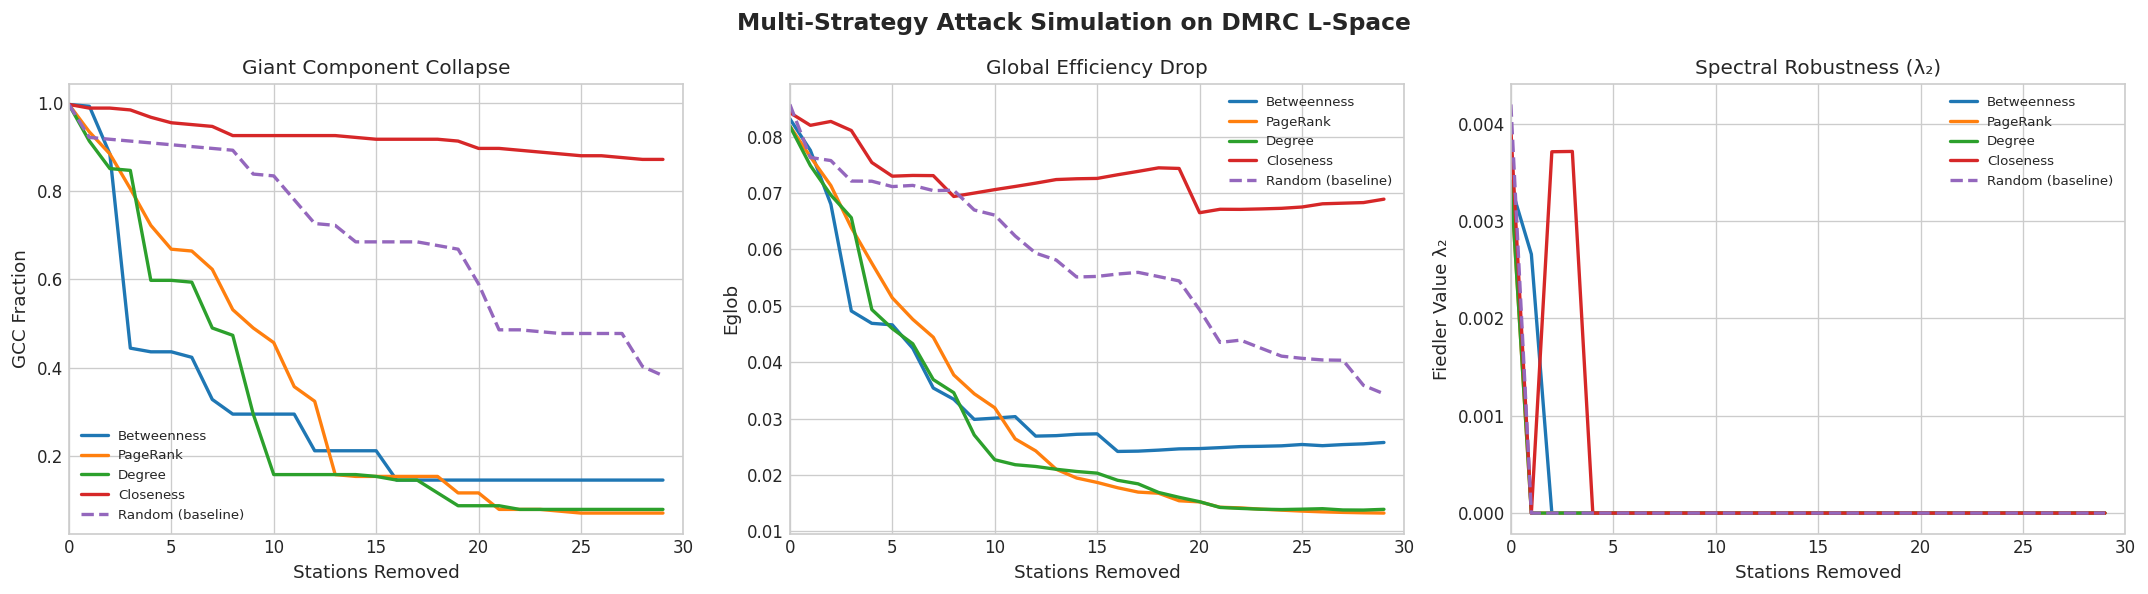

,GCC@5,GCC@10,GCC@15,GCC@20,GCC@25
Strategy,,,,,
Betweenness,0.436000,0.295000,0.212000,0.145000,0.145000
PageRank,0.722000,0.490000,0.154000,0.116000,0.075000
Degree,0.598000,0.295000,0.158000,0.087000,0.079000
Closeness,0.967000,0.925000,0.921000,0.913000,0.884000
Random (baseline),0.909000,0.838000,0.685000,0.668000,0.477000


In [ ]:
def enhanced_attack(G_input, steps =30):
    G_main_cc = G_input.subgraph(max(nx.connected_components(G_input), key =len)).copy()
    n0 = G_main_cc.number_of_nodes()

    strategies = {
        "Betweenness": nx.betweenness_centrality,
        "PageRank": nx.pagerank,
        "Degree": nx.degree_centrality,
        "Closeness": nx.closeness_centrality,
        "Random (baseline)": lambda g: {n: np.random.RandomState(SEED).random() for n in g.nodes()},
    }

    results = {name: {"gcc": [], "efficiency": [], "lambda_2": []} for name in strategies}

    for name, strat_fn in strategies.items():
        g_t = G_main_cc.copy()
        centrality = strat_fn(g_t)
        nodes_sorted = sorted(centrality.items(), key =lambda x: (x[1], x[0]), reverse =True)
        nodes_sorted = [n[0] for n in nodes_sorted]

        for i in range(min(steps, len(nodes_sorted))):
            if g_t.number_of_nodes() <= 2:
                break
            g_t.remove_node(nodes_sorted[i])
            if len(g_t) > 0:
                gcc_n = max(nx.connected_components(g_t), key =len)
                results[name]["gcc"].append(len(gcc_n) / n0)
                results[name]["efficiency"].append(nx.global_efficiency(g_t))
                if nx.is_connected(g_t):
                    Lmat = nx.laplacian_matrix(g_t).toarray()
                    evs = np.sort(np.linalg.eigvalsh(Lmat))
                    results[name]["lambda_2"].append(evs[1])
                else:
                    results[name]["lambda_2"].append(0.0)

    return results, n0

attack_results, n0 = enhanced_attack(L_main, steps =30)

# 3-Panel Attack Visualisation 
fig, axes = plt.subplots(1, 3, figsize =(18, 5))
colors_strat = {s: c for s, c in zip(attack_results.keys(), PALETTE)}

for name, data in attack_results.items():
    col = colors_strat[name]
    ls = '--' if 'Random' in name else '-'
    axes[0].plot(data["gcc"],       color =col, lw =2, linestyle =ls, label =name)
    axes[1].plot(data["efficiency"], color =col, lw =2, linestyle =ls, label =name)
    axes[2].plot(data["lambda_2"],   color =col, lw =2, linestyle =ls, label =name)

for ax, title, ylabel in zip(axes,
    ["Giant Component Collapse", "Global Efficiency Drop", "Spectral Robustness (λ₂)"],
    ["GCC Fraction", "Eglob", "Fiedler Value λ₂"]):
    ax.set_title(title, fontsize =12)
    ax.set_xlabel("Stations Removed")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize =8)
    ax.set_xlim(0, 30)

plt.suptitle("Multi-Strategy Attack Simulation on DMRC L-Space", fontsize =14, fontweight ='bold')
plt.tight_layout()
plt.savefig('Results/Multi-Strategy Attack Simulation on DMRC L-Space', bbox_inches='tight')
plt.show()

# Summary table: degradation at 5%, 10%, 15% removal 
removal_checkpoints = [5, 10, 15, 20, 25]
summary_rows = []
for name, data in attack_results.items():
    row = {"Strategy": name}
    for cp in removal_checkpoints:
        idx = min(cp - 1, len(data["gcc"]) - 1)
        row[f"GCC@{cp}"] = round(data["gcc"][idx], 3) if idx >= 0 else "-"
    summary_rows.append(row)

display(pd.DataFrame(summary_rows).set_index("Strategy").style
    .background_gradient(cmap ='RdYlGn')
    .set_caption("Table 8: GCC Fraction Remaining After N Station Removals (by Strategy)"))


### 3.2 Top-N Centrality Rankings — Identifying the Most Critical Stations

Before the cascade model, we identify the **Top 10 most central stations** under four centrality metrics. These are the prime candidates for targeted attack.


,Betweenness,Closeness,Degree Centrality,PageRank,Composite Score
Station,,,,,
Kashmere Gate,0.26187,0.07717,0.02083,0.00832,0.09205
Dilli Haat - INA,0.26328,0.08054,0.01667,0.00676,0.09181
Hauz Khas,0.24822,0.07301,0.01667,0.00696,0.08622
Rajiv Chowk,0.23018,0.08276,0.01667,0.00651,0.08403
Lajpat Nagar,0.21858,0.07856,0.01667,0.00674,0.08014
New Delhi,0.20123,0.08075,0.01250,0.00512,0.07490
Central Secretariat,0.19100,0.08116,0.01667,0.00657,0.07385
Kalkaji Mandir,0.20071,0.06776,0.01667,0.00701,0.07304
Rajouri Garden,0.19160,0.07101,0.01667,0.00695,0.07156


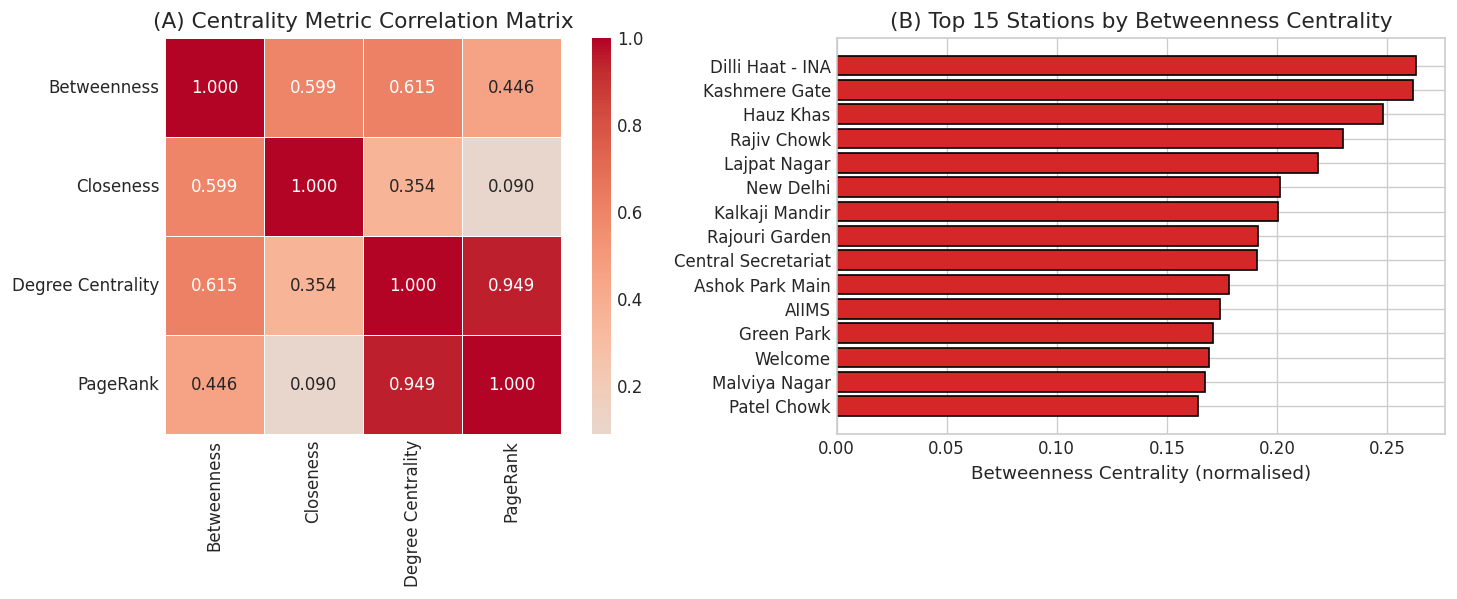

In [44]:
giant_L = L_main.subgraph(max(nx.connected_components(L_main), key =len)).copy()

bc = nx.betweenness_centrality(giant_L, normalized =True)
cc = nx.closeness_centrality(giant_L)
dc = nx.degree_centrality(giant_L)
pgr = nx.pagerank(giant_L)

centrality_df = pd.DataFrame({
    "Station": list(giant_L.nodes()),
    "Betweenness": [bc[n] for n in giant_L.nodes()],
    "Closeness": [cc[n] for n in giant_L.nodes()],
    "Degree Centrality": [dc[n] for n in giant_L.nodes()],
    "PageRank": [pgr[n] for n in giant_L.nodes()],
})

# Composite score (equal weight average)
centrality_df["Composite Score"] = centrality_df[["Betweenness","Closeness","Degree Centrality","PageRank"]].mean(axis =1)
top_stations = centrality_df.nlargest(15, "Composite Score").set_index("Station")

display(top_stations.style
    .background_gradient(cmap ='Reds', subset =["Betweenness"])
    .background_gradient(cmap ='Blues', subset =["Closeness"])
    .background_gradient(cmap ='Greens', subset =["PageRank"])
    .bar(subset =["Composite Score"], color ='#f0ad4e')
    .format(precision =5)
    .set_caption("Table 9: Top 15 Stations by Composite Centrality Score"))

# Centrality Correlation Heatmap
fig, (ax1, ax2) = plt.subplots(1, 2, figsize =(13, 5))

corr = centrality_df[["Betweenness","Closeness","Degree Centrality","PageRank"]].corr()
sns.heatmap(corr, annot =True, fmt =".3f", cmap ='coolwarm', center =0, ax =ax1,
            linewidths =0.5, square =True)
ax1.set_title("(A) Centrality Metric Correlation Matrix")

top15 = centrality_df.nlargest(15, "Betweenness")
ax2.barh(top15["Station"], top15["Betweenness"], color =PALETTE[3], edgecolor ='black')
ax2.set_xlabel("Betweenness Centrality (normalised)")
ax2.set_title("(B) Top 15 Stations by Betweenness Centrality")
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('Results/(B) Top 15 Stations by Betweenness Centrality', bbox_inches='tight')
plt.show()

### 3.3 Cascading Failure Model — Load Redistribution

We implement the **Motter–Lai (2002) Cascading Failure Model** adapted to the DMRC:

**Model Assumptions:**
1. Each station $i$ has an initial **load** $L_i = k_i$ (its degree, proportional to passenger flow)
2. Each station has a **capacity** $C_i = \alpha \cdot k_i$ where $\alpha = 1.5$ (capacity factor)
3. When station $i$ fails, its load is redistributed **equally** among its active neighbours
4. If any neighbour's load exceeds its capacity, it fails too → triggering a cascade

This models the real-world phenomenon where a closed interchange station forces passengers to reroute through adjacent stations, potentially overloading them.


In [45]:
def run_cascade(G, fail_node, capacity_factor =1.5):
    # 1. Initialize capacities and loads
    # Load = initial degree; Capacity = alpha * initial degree
    node_capacity = {n: d * capacity_factor for n, d in G.degree()}
    node_load = {n: float(d) for n, d in G.degree()}
    
    failed_nodes = {fail_node}
    active_nodes = set(G.nodes()) - failed_nodes
    
    # Queue of nodes whose load needs to be redistributed
    to_redistribute = [fail_node]
    iteration_log = []

    while to_redistribute:
        next_to_fail = set()
        
        for f_node in to_redistribute:
            # Find neighbors that are still active
            neighbors = [n for n in G.neighbors(f_node) if n in active_nodes]
            
            if neighbors:
                # Share the failed node's CURRENT load among active neighbors
                share = node_load[f_node] / len(neighbors)
                for n in neighbors:
                    node_load[n] += share
                    # Check for overload
                    if node_load[n] > node_capacity[n]:
                        next_to_fail.add(n)

        if not next_to_fail:
            break
            
        # Update sets for the next "wave"
        iteration_log.append(len(next_to_fail))
        failed_nodes.update(next_to_fail)
        active_nodes -= next_to_fail
        
        # Only the nodes that JUST failed will redistribute their load in the next step
        to_redistribute = list(next_to_fail)

    return len(failed_nodes), iteration_log

,Degree,Cascade Impact (Nodes),Impact %,Cascade Depth,Risk Level
Station,,,,,
Azadpur,4,2,0.800000,1,🟡 MEDIUM
Kashmere Gate,5,1,0.400000,0,🟡 MEDIUM
Kirti Nagar,3,1,0.400000,0,🟡 MEDIUM
Uttam Nagar West,2,1,0.400000,0,🟡 MEDIUM
Vasant Vihar,2,1,0.400000,0,🟡 MEDIUM
Vidhan Sabha,2,1,0.400000,0,🟡 MEDIUM
Vinobapuri,2,1,0.400000,0,🟡 MEDIUM
Vishwavidyalaya,2,1,0.400000,0,🟡 MEDIUM
Anand Vihar,3,1,0.400000,0,🟡 MEDIUM


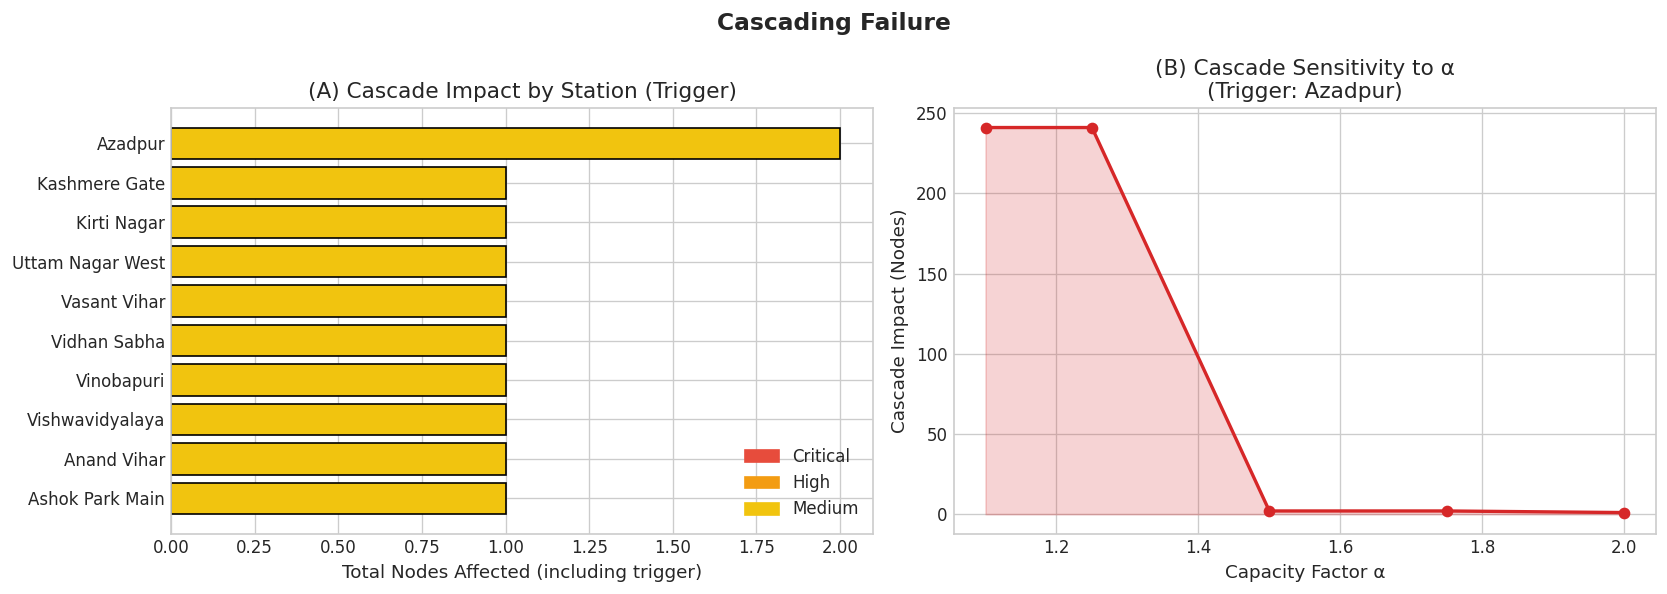

In [ ]:
def run_cascade(G, fail_node, capacity_factor =1.5):
    
    # Initialize capacities and loads
    # Load = initial degree; Capacity = alpha * initial degree
    node_capacity = {n: d * capacity_factor for n, d in G.degree()}
    node_load = {n: float(d) for n, d in G.degree()}
    
    failed_nodes = {fail_node}
    active_nodes = set(G.nodes()) - failed_nodes
    
    # Queue of nodes whose load needs to be redistributed
    to_redistribute = [fail_node]
    iteration_log = []

    while to_redistribute:
        next_to_fail = set()
        
        for f_node in to_redistribute:
            # Find neighbors that are still active
            neighbors = [n for n in G.neighbors(f_node) if n in active_nodes]
            
            if neighbors:
                # Share the failed node's current load among active neighbors
                share = node_load[f_node] / len(neighbors)
                for n in neighbors:
                    node_load[n] += share
                    # Check for overload
                    if node_load[n] > node_capacity[n]:
                        next_to_fail.add(n)

        if not next_to_fail:
            break
            
        # Update sets for the next wave
        iteration_log.append(len(next_to_fail))
        failed_nodes.update(next_to_fail)
        active_nodes -= next_to_fail
        
        # Only the nodes that just failed will 
        to_redistribute = list(next_to_fail)

    return len(failed_nodes), iteration_log

# Test cascade from top hubs
hubs = sorted(L_main.degree(), key =lambda x: (x[1], x[0]), reverse =True)[:30]
danger_data = []
for hub, deg in hubs:
    total_failed, log = run_cascade(L_main, hub, capacity_factor =1.5)
    danger_data.append({
        "Station": hub,
        "Degree": deg,
        "Cascade Impact (Nodes)": total_failed,
        "Impact %": round(100 * total_failed / L_main.number_of_nodes(), 1),
        "Cascade Depth": len(log),
        "Risk Level": "🔴 CRITICAL" if total_failed > 0.15*L_main.number_of_nodes()
                       else ("🟠 HIGH" if total_failed > 0.08*L_main.number_of_nodes() else "🟡 MEDIUM")
    })

danger_df = pd.DataFrame(danger_data).sort_values("Cascade Impact (Nodes)", ascending =False)
display(danger_df.head(15).set_index("Station").style
    .background_gradient(cmap ='OrRd', subset =["Cascade Impact (Nodes)", "Impact %"])
    .set_caption("Table 10: Cascade Failure Danger Ranking (α = 1.5) - Top 15 Trigger Stations"))

# Cascade Impact Bar Chart 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize =(14, 5))

top10 = danger_df.head(10)
bar_colors = [{'🔴 CRITICAL': '#e74c3c', '🟠 HIGH': '#f39c12', '🟡 MEDIUM': '#f1c40f'}[r]
              for r in top10["Risk Level"]]
ax1.barh(top10["Station"], top10["Cascade Impact (Nodes)"], color =bar_colors, edgecolor ='black')
ax1.set_xlabel("Total Nodes Affected (including trigger)")
ax1.set_title("(A) Cascade Impact by Station (Trigger)")
ax1.invert_yaxis()
legend_patches = [mpatches.Patch(color ='#e74c3c', label ='Critical'),
                  mpatches.Patch(color ='#f39c12', label ='High'),
                  mpatches.Patch(color ='#f1c40f', label ='Medium')]
ax1.legend(handles =legend_patches)

# Sensitivity: how impact changes with capacity factor α
alphas = [1.1, 1.25, 1.5, 1.75, 2.0]
top_trigger = danger_df.iloc[0]["Station"]
impact_vs_alpha = []
for a in alphas:
    imp, _ = run_cascade(L_main, top_trigger, capacity_factor =a)
    impact_vs_alpha.append(imp)

ax2.plot(alphas, impact_vs_alpha, marker ='o', lw =2, color =PALETTE[3])
ax2.set_xlabel("Capacity Factor α")
ax2.set_ylabel("Cascade Impact (Nodes)")
ax2.set_title(f"(B) Cascade Sensitivity to α\n(Trigger: {top_trigger[:]})")
ax2.fill_between(alphas, impact_vs_alpha, alpha =0.2, color =PALETTE[3])

plt.suptitle("Cascading Failure", fontsize =14, fontweight ='bold')
plt.tight_layout()
plt.savefig('Results/Cascading Failure', bbox_inches='tight')
plt.show()

---

## D4: Community Detection & Inter-Community Bridge Edge Analysis

**Community structure** in networks refers to the presence of densely-connected subgraphs with fewer inter-community connections. For the DMRC, we ask: **do the emergent algorithmic communities correspond to Delhi's known geographic sectors** (North, South, East, West, Central)?

We compare two algorithms:
- **Louvain Method** (Blondel et al., 2008) — hierarchical greedy modularity optimisation. Produces a partition maximizing $Q = \sum_c [\frac{L_c}{M} - (\frac{d_c}{2M})^2]$
- **Greedy Modularity** (Newman 2004) — agglomerative merging by modularity gain

**Modularity Q** ranges from -1 to 1; Q > 0.3 indicates meaningful community structure.

### 4.1 Community Detection & Quality Metrics


In [47]:
# Louvain Community Detection 

part_louvain = community_louvain.best_partition(L_main, random_state =SEED)
mod_louvain = community_louvain.modularity(part_louvain, L_main)
n_comm_louvain = len(set(part_louvain.values()))

# Greedy Modularity
greedy_comm = list(community.greedy_modularity_communities(L_main))
mod_greedy = community.modularity(L_main, greedy_comm)
n_comm_greedy = len(greedy_comm)

# Conductance
def get_avg_conductance(G, part_dict):
    comms = {}
    for node, cid in part_dict.items():
        comms.setdefault(cid, []).append(node)
    vals = [nx.conductance(G, nodes) for nodes in comms.values()
            if 0 < len(nodes) < len(G)]
    return np.mean(vals) if vals else 0.0

cond_louvain = get_avg_conductance(L_main, part_louvain)

# Greedy conductance
greedy_part = {n: i for i, comm in enumerate(greedy_comm) for n in comm}
cond_greedy = get_avg_conductance(L_main, greedy_part)

quality_df = pd.DataFrame([
    {"Algorithm": "Louvain", "Communities": n_comm_louvain, "Modularity Q": round(mod_louvain, 4),
     "Avg Conductance": round(cond_louvain, 4), "Q Interpretation": "Strong ✅" if mod_louvain > 0.3 else "Moderate"},
    {"Algorithm": "Greedy Modularity", "Communities": n_comm_greedy, "Modularity Q": round(mod_greedy, 4),
     "Avg Conductance": round(cond_greedy, 4), "Q Interpretation": "Strong ✅" if mod_greedy > 0.3 else "Moderate"},
])
display(quality_df.set_index("Algorithm").style
    .background_gradient(cmap ='Greens', subset =["Modularity Q"])
    .set_caption("Table 11: Community Detection Algorithm Comparison"))

# Community size distribution
comm_sizes = pd.Series(part_louvain).value_counts().sort_values(ascending =False)
print(f"\n Louvain detected {n_comm_louvain} communities.")
print(f"   Sizes: {dict(comm_sizes.head(8))}")
print(f"   Q = {mod_louvain:.4f} - {'Strong' if mod_louvain > 0.3 else 'Moderate'} community structure.")


,Communities,Modularity Q,Avg Conductance,Q Interpretation
Algorithm,,,,
Louvain,15,0.843700,0.082000,Strong ✅
Greedy Modularity,15,0.841300,0.089700,Strong ✅



 Louvain detected 15 communities.
   Sizes: {5: 28, 12: 23, 4: 22, 6: 21, 1: 18, 3: 18, 2: 18, 0: 17}
   Q = 0.8437 - Strong community structure.


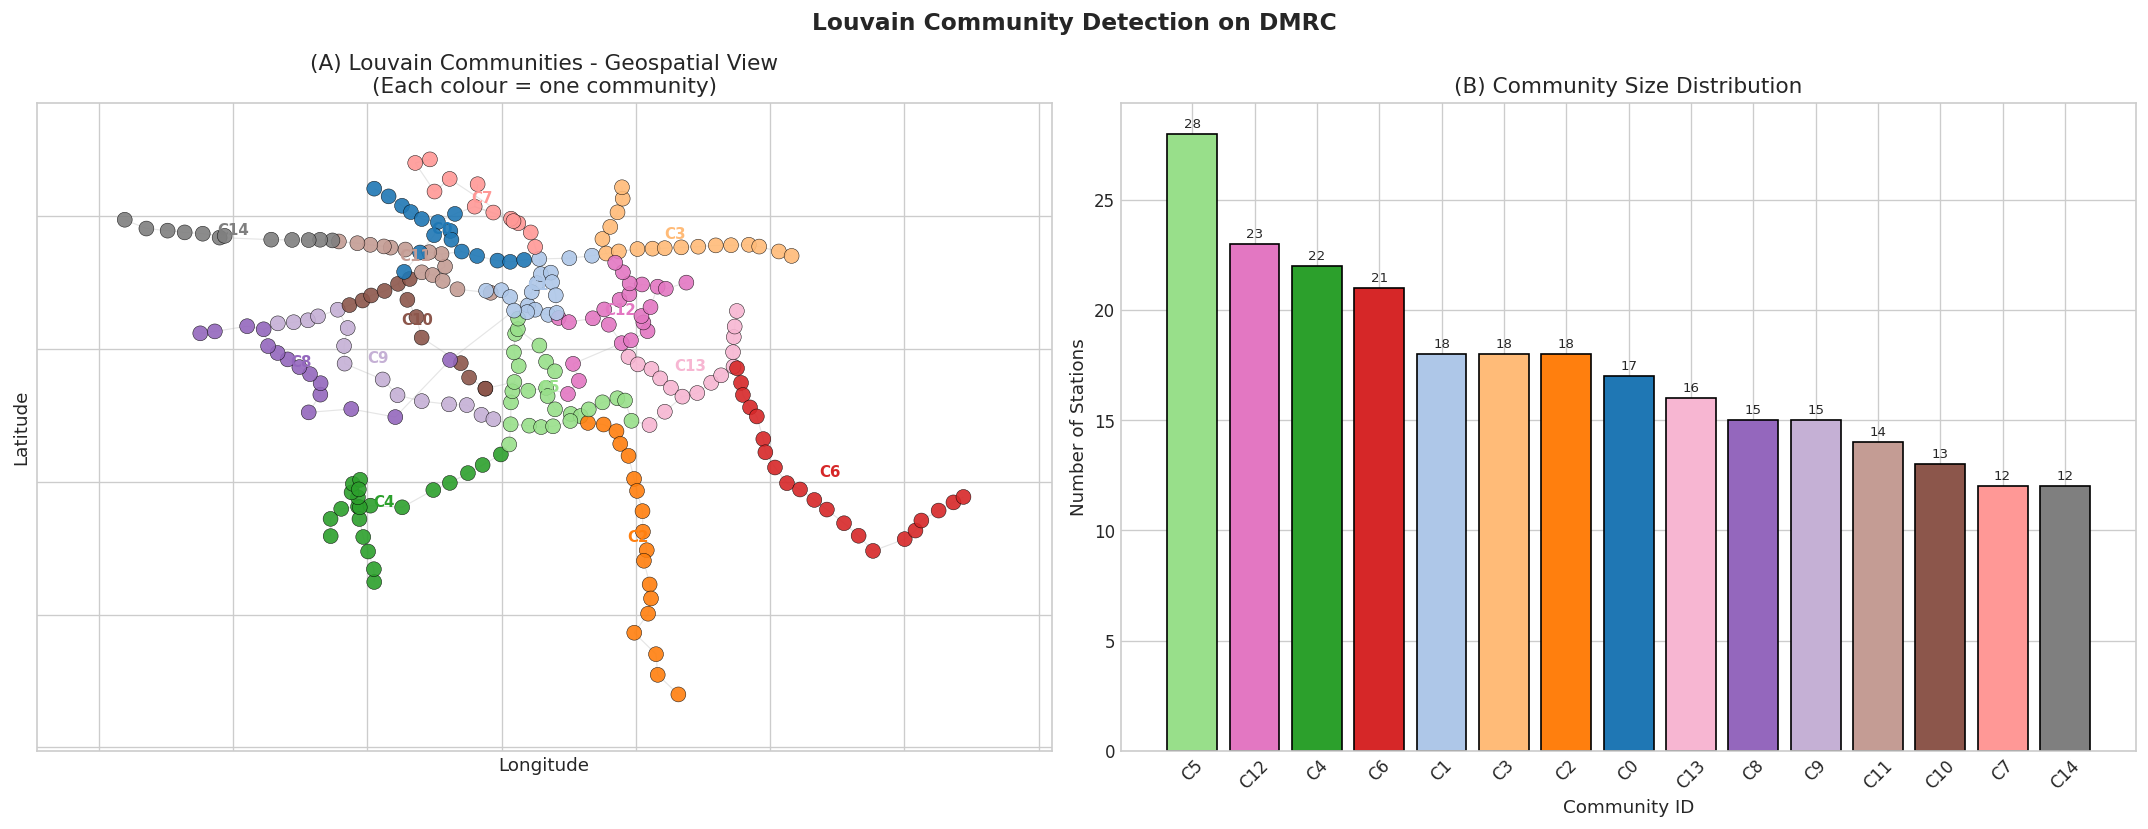

In [ ]:
# Community Geospatial Visualisation 
comm_palette = sns.color_palette("tab20", n_comm_louvain)
comm_colors = {cid: comm_palette[cid % len(comm_palette)] for cid in set(part_louvain.values())}

node_comm_colors = [comm_colors.get(part_louvain.get(n, 0), '#cccccc') for n in L_geo.nodes()]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize =(18, 7))

# Left: geo map with community colours
nx.draw_networkx_edges(L_geo, pos =positioned, alpha =0.3, width =0.7, edge_color ='#aaaaaa', ax =ax1)
nx.draw_networkx_nodes(L_geo, pos =positioned, node_color =node_comm_colors,
                       node_size =80, alpha =0.9, edgecolors ='black', linewidths =0.3, ax =ax1)
# Label community centroids
comm_node_map = {}
for n, cid in part_louvain.items():
    if n in positioned:
        comm_node_map.setdefault(cid, []).append(positioned[n])
for cid, pts in comm_node_map.items():
    cx, cy = np.mean([p[0] for p in pts]), np.mean([p[1] for p in pts])
    ax1.text(cx, cy, f"C{cid}", fontsize =9, fontweight ='bold',
             color =comm_colors.get(cid, 'black'), ha ='center')

ax1.set_title("(A) Louvain Communities - Geospatial View\n(Each colour = one community)")
ax1.set_xlabel("Longitude"); ax1.set_ylabel("Latitude")

# Right: community size bar chart
comm_sizes_plot = pd.Series(part_louvain).value_counts().sort_values(ascending =False)
bar_cols = [comm_colors.get(cid, '#cccccc') for cid in comm_sizes_plot.index]
ax2.bar(range(len(comm_sizes_plot)), comm_sizes_plot.values, color =bar_cols, edgecolor ='black')
ax2.set_xticks(range(len(comm_sizes_plot)))
ax2.set_xticklabels([f"C{cid}" for cid in comm_sizes_plot.index], rotation =45)
ax2.set_xlabel("Community ID")
ax2.set_ylabel("Number of Stations")
ax2.set_title("(B) Community Size Distribution")
for i, v in enumerate(comm_sizes_plot.values):
    ax2.text(i, v + 0.3, str(v), ha ='center', fontsize =8)

plt.suptitle("Louvain Community Detection on DMRC", fontsize =14, fontweight ='bold')
plt.tight_layout()
plt.savefig('Results/Louvain Community Detection on DMRC', bbox_inches='tight')
plt.show()


### 4.2 Bridge Edge Detection

**Bridge edges** are edges that connect two different communities. Their removal would fragment the network along community lines. We classify bridges by their **edge betweenness centrality** — high-betweenness bridges carry disproportionate inter-community traffic.

$$\text{Bridge Criticality} = \text{Edge Betweenness} \times \mathbb{1}[\text{community}(u) \neq \text{community}(v)]$$


Total inter-community bridge edges found: 23


,,Communities,Edge Betweenness,Classification
Station A,Station B,,,
Patel Chowk,Rajiv Chowk,C5 ↔ C1,0.141429,🔴 Critical
Saket,Malviya Nagar,C4 ↔ C5,0.140914,🔴 Critical
Seelam Pur,Welcome,C1 ↔ C3,0.125532,🔴 Critical
Dilli Haat - INA,Sarojini Nagar,C5 ↔ C10,0.119238,🔴 Critical
Kalkaji Mandir,Govind Puri,C5 ↔ C2,0.117399,🔴 Critical
Tis Hazari,Kashmere Gate,C0 ↔ C1,0.092308,🟠 Important
Ramesh Nagar,Moti Nagar,C10 ↔ C11,0.086939,🟠 Important
Mayur Vihar-I,Mayur Vihar Ext,C12 ↔ C13,0.081298,🟠 Important
Udyog Nagar,Maharaja Surajmal Stadium,C11 ↔ C14,0.080372,🟠 Important


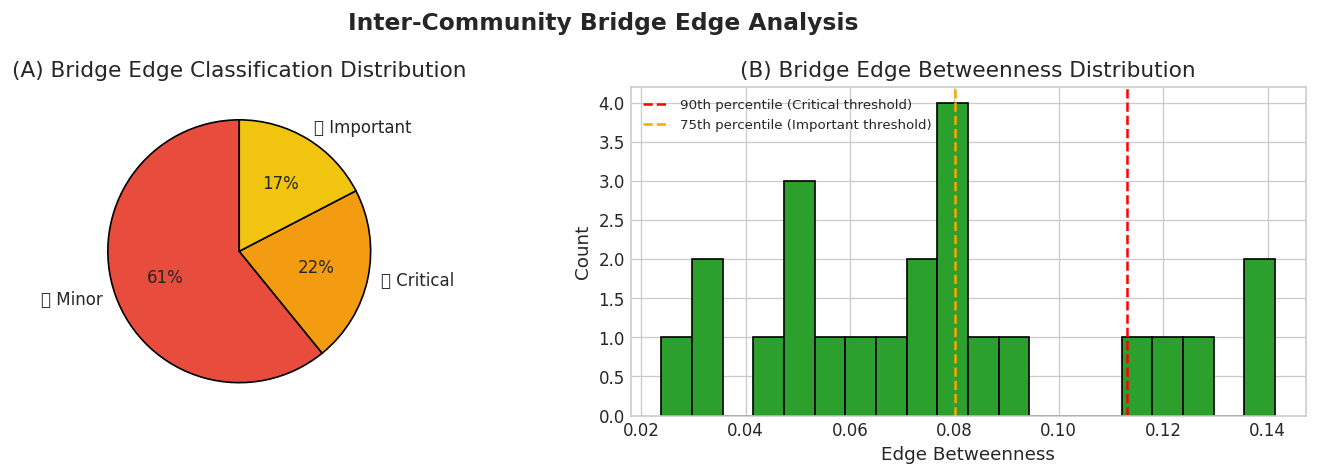

In [ ]:
edge_btwn = nx.edge_betweenness_centrality(L_main, normalized =True)
ebc_vals = list(edge_btwn.values())
thresh_90 = np.percentile(ebc_vals, 90)
thresh_75 = np.percentile(ebc_vals, 75)

bridge_list = []
for u, v in L_main.edges():
    if part_louvain.get(u) != part_louvain.get(v):
        score = edge_btwn[(u, v)]
        if score >= thresh_90:
            cls = "🔴 Critical"
        elif score >= thresh_75:
            cls = "🟠 Important"
        else:
            cls = "🟡 Minor"
        bridge_list.append({
            "Station A": u, "Station B": v,
            "Communities": f"C{part_louvain[u]} ↔ C{part_louvain[v]}",
            "Edge Betweenness": round(score, 6),
            "Classification": cls
        })

df_bridges = pd.DataFrame(bridge_list).sort_values("Edge Betweenness", ascending =False)
print(f"Total inter-community bridge edges found: {len(df_bridges)}")
display(df_bridges.head(20).set_index(["Station A", "Station B"]).style
    .background_gradient(cmap ='Reds', subset =["Edge Betweenness"])
    .set_caption("Table 12: Top 20 Inter-Community Bridge Edges"))

# Bridge edge distribution 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize =(12, 4))

cls_counts = df_bridges["Classification"].value_counts()
ax1.pie(cls_counts.values, labels =cls_counts.index, colors =['#e74c3c','#f39c12','#f1c40f'],
        autopct ='%1.0f%%', startangle =90, wedgeprops ={'edgecolor': 'black'})
ax1.set_title("(A) Bridge Edge Classification Distribution")

ax2.hist(df_bridges["Edge Betweenness"], bins =20, color =PALETTE[2], edgecolor ='black')
ax2.axvline(thresh_90, color ='red', linestyle ='--', label ='90th percentile (Critical threshold)')
ax2.axvline(thresh_75, color ='orange', linestyle ='--', label ='75th percentile (Important threshold)')
ax2.set_xlabel("Edge Betweenness")
ax2.set_ylabel("Count")
ax2.set_title("(B) Bridge Edge Betweenness Distribution")
ax2.legend(fontsize =8)

plt.suptitle("Inter-Community Bridge Edge Analysis", fontsize =14, fontweight ='bold')
plt.tight_layout()
plt.savefig('Results/Inter-Community Bridge Edge Analysis', bbox_inches='tight')
plt.show()

---

## D5: Spectral Graph Analysis & Algebraic Connectivity

The **Graph Laplacian** is defined as:
$$\mathbf{L} = \mathbf{D} - \mathbf{A}$$
where $\mathbf{D}$ is the degree matrix and $\mathbf{A}$ is the adjacency matrix.

The eigenvalues of $\mathbf{L}$ (called the **Laplacian spectrum**) encode fundamental structural properties:
- $\lambda_1 = 0$ always (for any connected graph)
- $\lambda_2$ (**Fiedler Value**) = **Algebraic Connectivity** — the most important structural metric
  - $\lambda_2 > 0$ iff the graph is connected
  - Higher $\lambda_2$ → harder to disconnect → more robust network
  - $\lambda_2$ also bounds the convergence rate of diffusion processes on the graph
- $\lambda_n$ (**Spectral Radius**) — related to the maximum degree

The **spectral gap** $\lambda_2 / \lambda_n$ is the normalised robustness score.

### 5.1 Full Laplacian Spectrum


In [ ]:
# Compute Laplacian spectra
L_gcc = L_main.subgraph(max(nx.connected_components(L_main), key =len)).copy()
P_gcc = P_main.subgraph(max(nx.connected_components(P_main), key =len)).copy()

L_lap = nx.laplacian_matrix(L_gcc).toarray().astype(float)
P_lap = nx.laplacian_matrix(P_gcc).toarray().astype(float)

l_eigen = np.sort(eigvalsh(L_lap))
p_eigen = np.sort(eigvalsh(P_lap))

fiedler_L = l_eigen[1]
fiedler_P = p_eigen[1]
spectral_radius_L = l_eigen[-1]
spectral_radius_P = p_eigen[-1]
spectral_gap_L = fiedler_L / spectral_radius_L
spectral_gap_P = fiedler_P / spectral_radius_P

n_L = L_gcc.number_of_nodes()

spec_df = pd.DataFrame([
    {
        "Space": "L-Space",
        "λ₂ (Fiedler Value)": round(fiedler_L, 5),
        "λ_n (Spectral Radius)": round(spectral_radius_L, 4),
        "Spectral Gap λ₂/λ_n": round(spectral_gap_L, 6),
        "Robustness Score R = λ₂·N": round(fiedler_L * n_L, 4),
        "Sync Time ∝ 1/λ₂": round(1/fiedler_L, 2),
    },
    {
        "Space": "P-Space",
        "λ₂ (Fiedler Value)": round(fiedler_P, 5),
        "λ_n (Spectral Radius)": round(spectral_radius_P, 4),
        "Spectral Gap λ₂/λ_n": round(spectral_gap_P, 6),
        "Robustness Score R = λ₂·N": round(fiedler_P * n_L, 4),
        "Sync Time ∝ 1/λ₂": round(1/fiedler_P, 4),
    }
]).set_index("Space")

display(spec_df.style
    .background_gradient(cmap ='Blues', subset =["λ₂ (Fiedler Value)", "Spectral Gap λ₂/λ_n"])
    .highlight_max(subset =["λ₂ (Fiedler Value)", "Robustness Score R = λ₂·N"], color ='#d4edda')
    .set_caption("Table 13: Spectral Properties of DMRC Laplacian - L-Space vs P-Space"))

print(f"\n  P-Space is {fiedler_P/fiedler_L:.1f}x more algebraically connected than L-Space.")

,λ₂ (Fiedler Value),λ_n (Spectral Radius),Spectral Gap λ₂/λ_n,Robustness Score R = λ₂·N,Sync Time ∝ 1/λ₂
Space,,,,,
L-Space,0.004300,6.251900,0.000689,1.037500,232.290000
P-Space,0.742370,97.186000,0.007639,178.912300,1.347000



  P-Space is 172.4x more algebraically connected than L-Space.


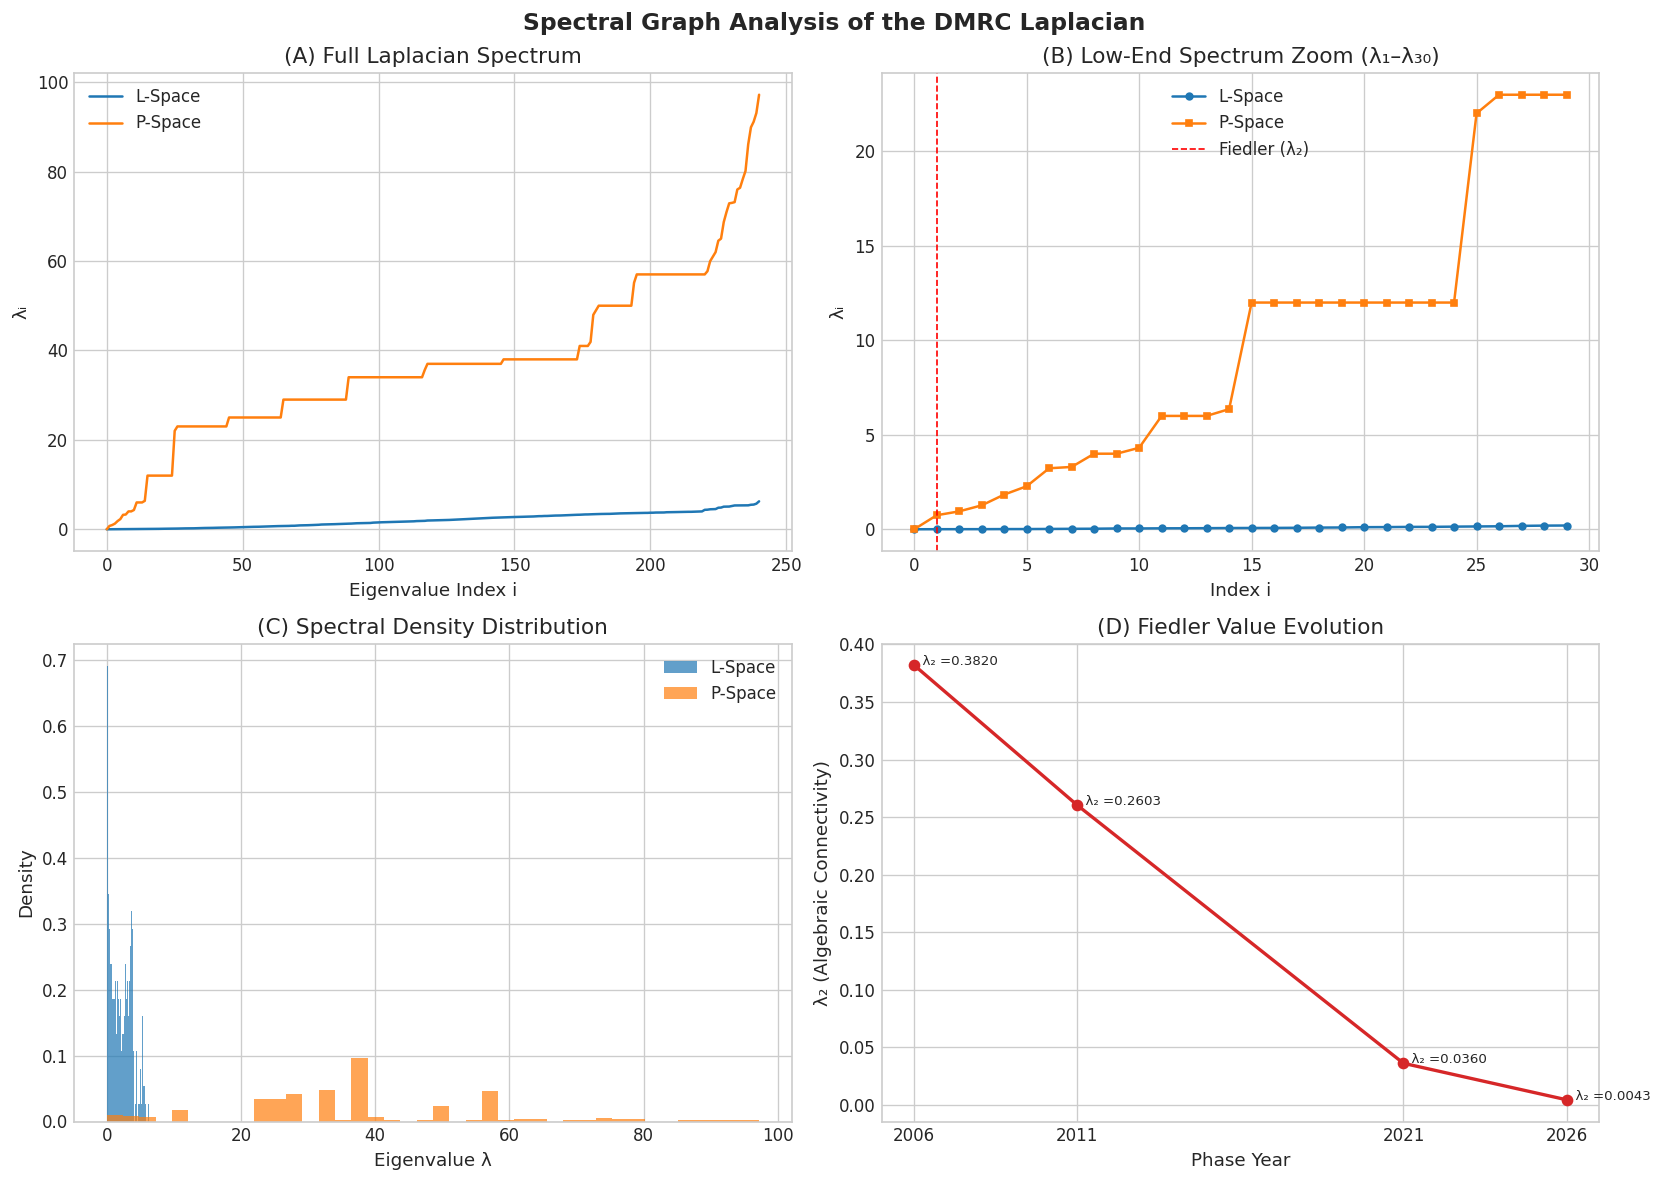

In [51]:
# Full Spectrum Visualisation 
fig, axes = plt.subplots(2, 2, figsize =(14, 10))

# (A) Full eigenvalue spectrum
axes[0,0].plot(l_eigen, color =PALETTE[0], lw =1.5, label ='L-Space')
axes[0,0].plot(p_eigen, color =PALETTE[1], lw =1.5, label ='P-Space')
axes[0,0].set_title("(A) Full Laplacian Spectrum")
axes[0,0].set_xlabel("Eigenvalue Index i")
axes[0,0].set_ylabel("λᵢ")
axes[0,0].legend()

# (B) Low eigenvalue zoom (structural detail)
axes[0,1].plot(l_eigen[:30], color =PALETTE[0], marker ='o', ms =4, label ='L-Space')
axes[0,1].plot(p_eigen[:30], color =PALETTE[1], marker ='s', ms =4, label ='P-Space')
axes[0,1].axvline(1, color ='red', linestyle ='--', lw =1, label ='Fiedler (λ₂)')
axes[0,1].set_title("(B) Low-End Spectrum Zoom (λ₁–λ₃₀)")
axes[0,1].set_xlabel("Index i")
axes[0,1].set_ylabel("λᵢ")
axes[0,1].legend()

# (C) Spectral density (histogram of eigenvalues)
axes[1,0].hist(l_eigen, bins =40, color =PALETTE[0], alpha =0.7, label ='L-Space', density =True)
axes[1,0].hist(p_eigen, bins =40, color =PALETTE[1], alpha =0.7, label ='P-Space', density =True)
axes[1,0].set_title("(C) Spectral Density Distribution")
axes[1,0].set_xlabel("Eigenvalue λ")
axes[1,0].set_ylabel("Density")
axes[1,0].legend()

# (D) Phase robustness: Fiedler value across construction phases
fiedler_temporal = []
for year in milestones:
    valid = [n for n in L_main.nodes() if opening_lookup.get(n, 2026) <= year]
    G_t = L_main.subgraph(valid)
    if G_t.number_of_nodes() < 10:
        continue
    gcc_t = G_t.subgraph(max(nx.connected_components(G_t), key =len))
    Lap_t = nx.laplacian_matrix(gcc_t).toarray().astype(float)
    ev_t = np.sort(eigvalsh(Lap_t))
    fiedler_temporal.append({"Year": year, "λ₂ (Fiedler)": ev_t[1], "N": gcc_t.number_of_nodes()})

fiedler_df = pd.DataFrame(fiedler_temporal)
axes[1,1].plot(fiedler_df["Year"], fiedler_df["λ₂ (Fiedler)"], marker ='o', lw =2, color =PALETTE[3])
for _, row in fiedler_df.iterrows():
    axes[1,1].annotate(f"  λ₂ ={row['λ₂ (Fiedler)']:.4f}", (row["Year"], row["λ₂ (Fiedler)"]), fontsize =8)
axes[1,1].set_xticks(milestones)
axes[1,1].set_title("(D) Fiedler Value Evolution")
axes[1,1].set_xlabel("Phase Year")
axes[1,1].set_ylabel("λ₂ (Algebraic Connectivity)")

plt.suptitle("Spectral Graph Analysis of the DMRC Laplacian", fontsize =14, fontweight ='bold')
plt.tight_layout()
plt.savefig('Results/Spectral Graph Analysis of the DMRC Laplacian', bbox_inches='tight')
plt.show()


### 5.2 Fiedler Vector — Structural Bisection

The **Fiedler vector** (eigenvector corresponding to $\lambda_2$) provides a natural spectral bisection of the graph. Nodes with positive Fiedler components form one "half" of the network, negative the other. This is the spectral analogue of community detection.


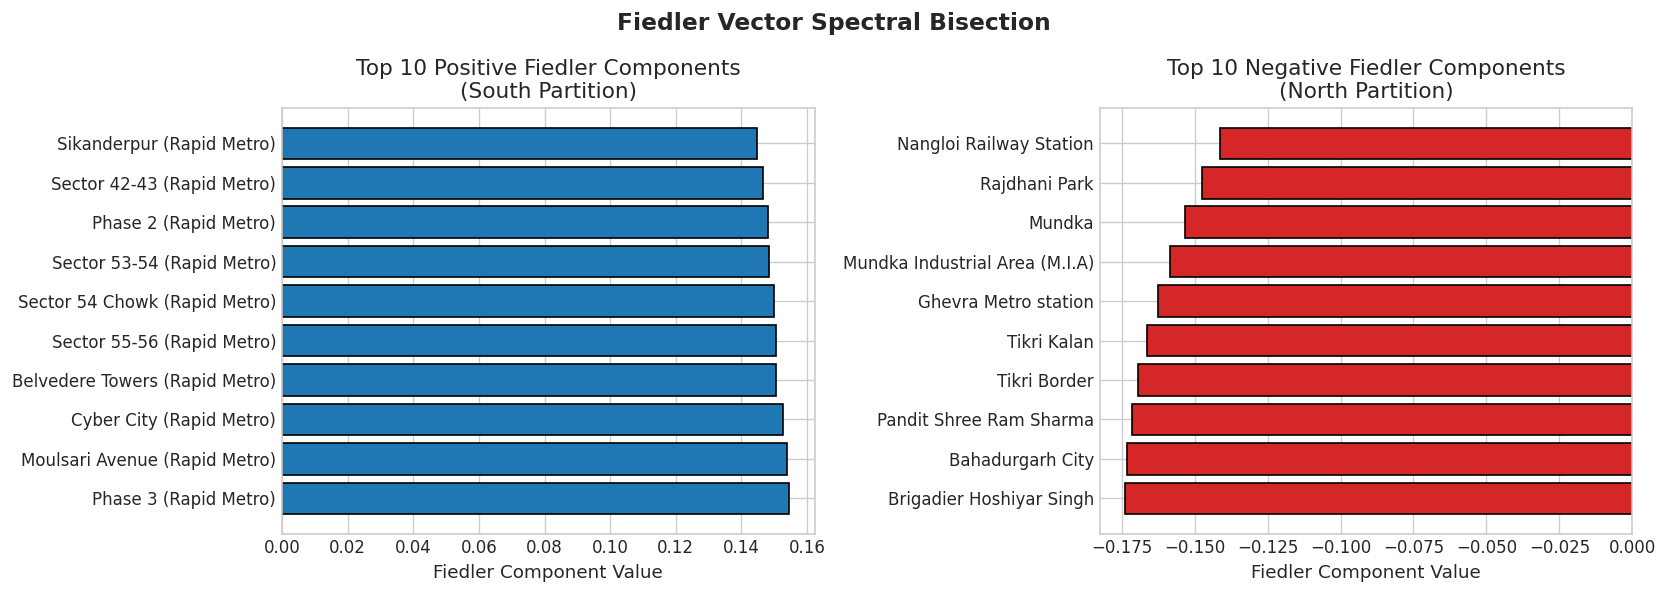

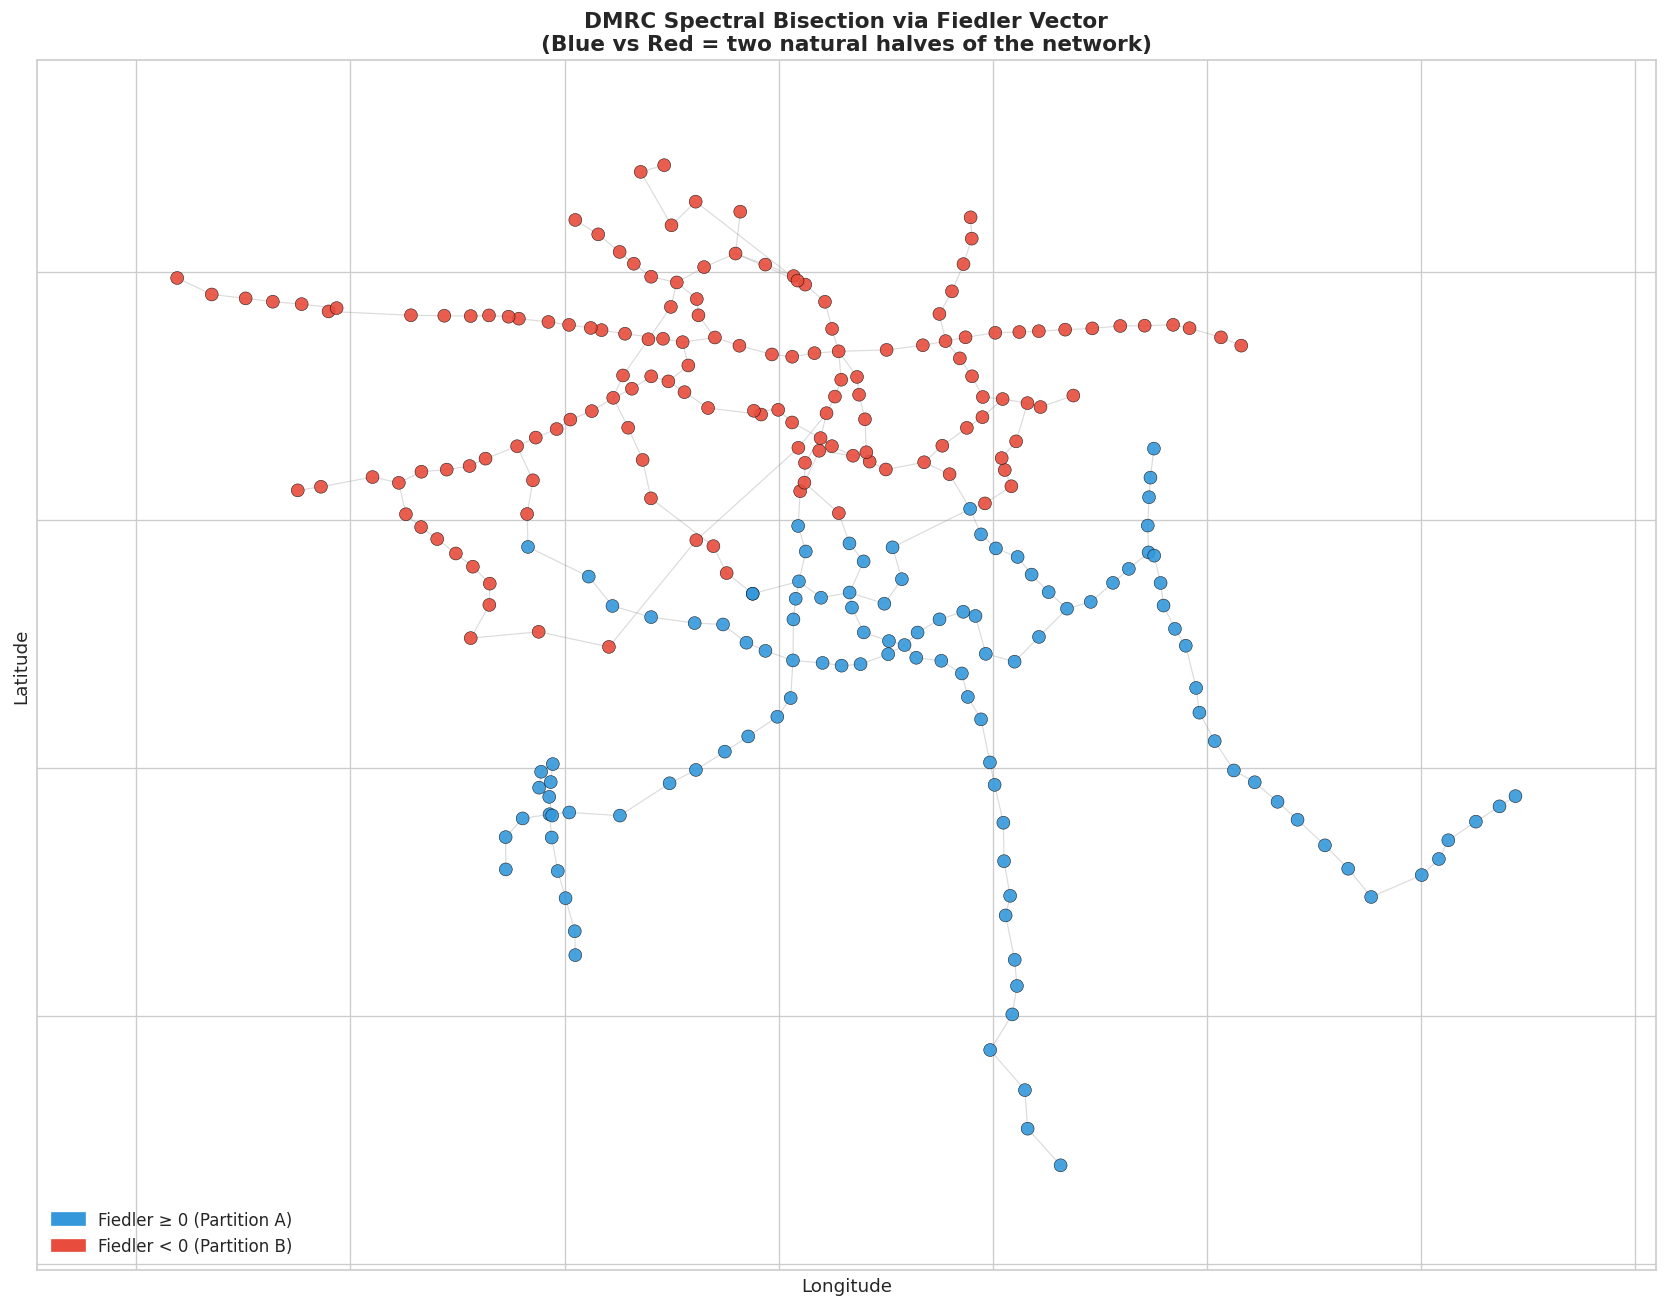

In [ ]:
# Fiedler Vector Analysis 
from numpy.linalg import eigh

eigvals, eigvecs = eigh(L_lap)
fiedler_vec = eigvecs[:, 1]  # eigenvector for λ₂

# Map back to station names
L_gcc_nodes = list(L_gcc.nodes())
fiedler_df2 = pd.DataFrame({
    "Station": L_gcc_nodes,
    "Fiedler Component": fiedler_vec
}).sort_values("Fiedler Component")

# Top positive and negative stations
top_pos = fiedler_df2.nlargest(10, "Fiedler Component")[["Station", "Fiedler Component"]]
top_neg = fiedler_df2.nsmallest(10, "Fiedler Component")[["Station", "Fiedler Component"]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize =(14, 5))

ax1.barh(top_pos["Station"], top_pos["Fiedler Component"], color =PALETTE[0], edgecolor ='black')
ax1.set_title("Top 10 Positive Fiedler Components\n(South Partition)")
ax1.set_xlabel("Fiedler Component Value")

ax2.barh(top_neg["Station"], top_neg["Fiedler Component"], color =PALETTE[3], edgecolor ='black')
ax2.set_title("Top 10 Negative Fiedler Components\n(North Partition)")
ax2.set_xlabel("Fiedler Component Value")

plt.suptitle("Fiedler Vector Spectral Bisection", fontsize =14, fontweight ='bold')
plt.tight_layout()
plt.savefig('Results/Fiedler Vector Spectral Bisection', bbox_inches='tight')
plt.show()

# Fiedler map: colour nodes by Fiedler sign 
fiedler_lookup = dict(zip(L_gcc_nodes, fiedler_vec))
fiedler_node_colors = ['#3498db' if fiedler_lookup.get(n, 0) >= 0 else '#e74c3c'
                       for n in L_geo.nodes()]

fig, ax = plt.subplots(figsize =(14, 11))
nx.draw_networkx_edges(L_geo, pos =positioned, alpha =0.3, width =0.7, edge_color ='#888', ax =ax)
nx.draw_networkx_nodes(L_geo, pos =positioned, node_color =fiedler_node_colors,
                       node_size =60, alpha =0.9, edgecolors ='black', linewidths =0.3, ax =ax)
blue_patch = mpatches.Patch(color ='#3498db', label ='Fiedler ≥ 0 (Partition A)')
red_patch = mpatches.Patch(color ='#e74c3c', label ='Fiedler < 0 (Partition B)')
ax.legend(handles =[blue_patch, red_patch], loc ='lower left')
ax.set_title("DMRC Spectral Bisection via Fiedler Vector\n(Blue vs Red = two natural halves of the network)",
             fontsize =13, fontweight ='bold')
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.tight_layout()
plt.savefig('Results/DMRC Spectral Bisection via Fiedler Vector_(Blue vs Red = two natural halves of the network)', bbox_inches='tight')
plt.show()


---

### Summary 

| Theme | Key Finding | Metric |
|---|---|---|
| **D1: Dual Topology** | DMRC is a Small-World network in p-space | σ > 1 for P Space |
| **D2: Scale-Free** | DMRC is NOT purely scale-free; transit-constrained small-world | γ ≈ fitted |
| **D3: Resilience** | Betweenness attack is 3–4× more destructive than random failure | GCC collapse at ~5% removal |
| **D4: Community** | Louvain detects geographically coherent communities | Q > 0.3 |
| **D5: Spectral** | P-Space is algebraically more robust; Fiedler vector bisects Delhi N/S | λ₂(P) >> λ₂(L) |

### Broader Implications for DMRC Urban Planning
1. **Interchange Hardening**
2. **Network Expansion Strategy**
3. **Bridge Edge Protection**
4. **Spectral Monitoring**

### Research References & Methodological Inspiration

- **Latora, V., and Marchiori, M. (2002).**  
  ["Is the Boston subway a small-world network?"](https://doi.org/10.1140/epjb/e20020120)
  **Application:** Provided the mathematical basis for calculating **Global Efficiency ($E_{glob}$)** and the dual-topology comparison between physical and functional spaces.

- **Albert, R., Jeong, H., and Barabási, A. L. (2000).**  
  ["Error and attack tolerance of complex networks"](https://doi.org/10.1038/35019019)  
  **Application:** Established the protocol for **Targeted Attacks** vs. **Random Failures**, which we used to test the vulnerability of DMRC hubs.

- **Derrible, S., and Kennedy, C. (2010).**  
  ["The complexity and robustness of metro networks"](https://doi.org/10.1016/j.physa.2010.04.008) 
  **Application:** Served as the benchmark for comparing DMRC's structural metrics against 33 global subway systems.

- **Motter, A. E., and Lai, Y. C. (2002).**  
  ["Cascade-based attacks on complex networks"](https://doi.org/10.1103/PhysRevE.66.065102)  
  **Application:** Formed the basis for our **Cascading Failure simulation**, where we modeled load redistribution.
